In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.dpi'] = 300 
plt.rcParams['savefig.dpi'] = 300

### GCR by Intersectional Identity (Implicit)

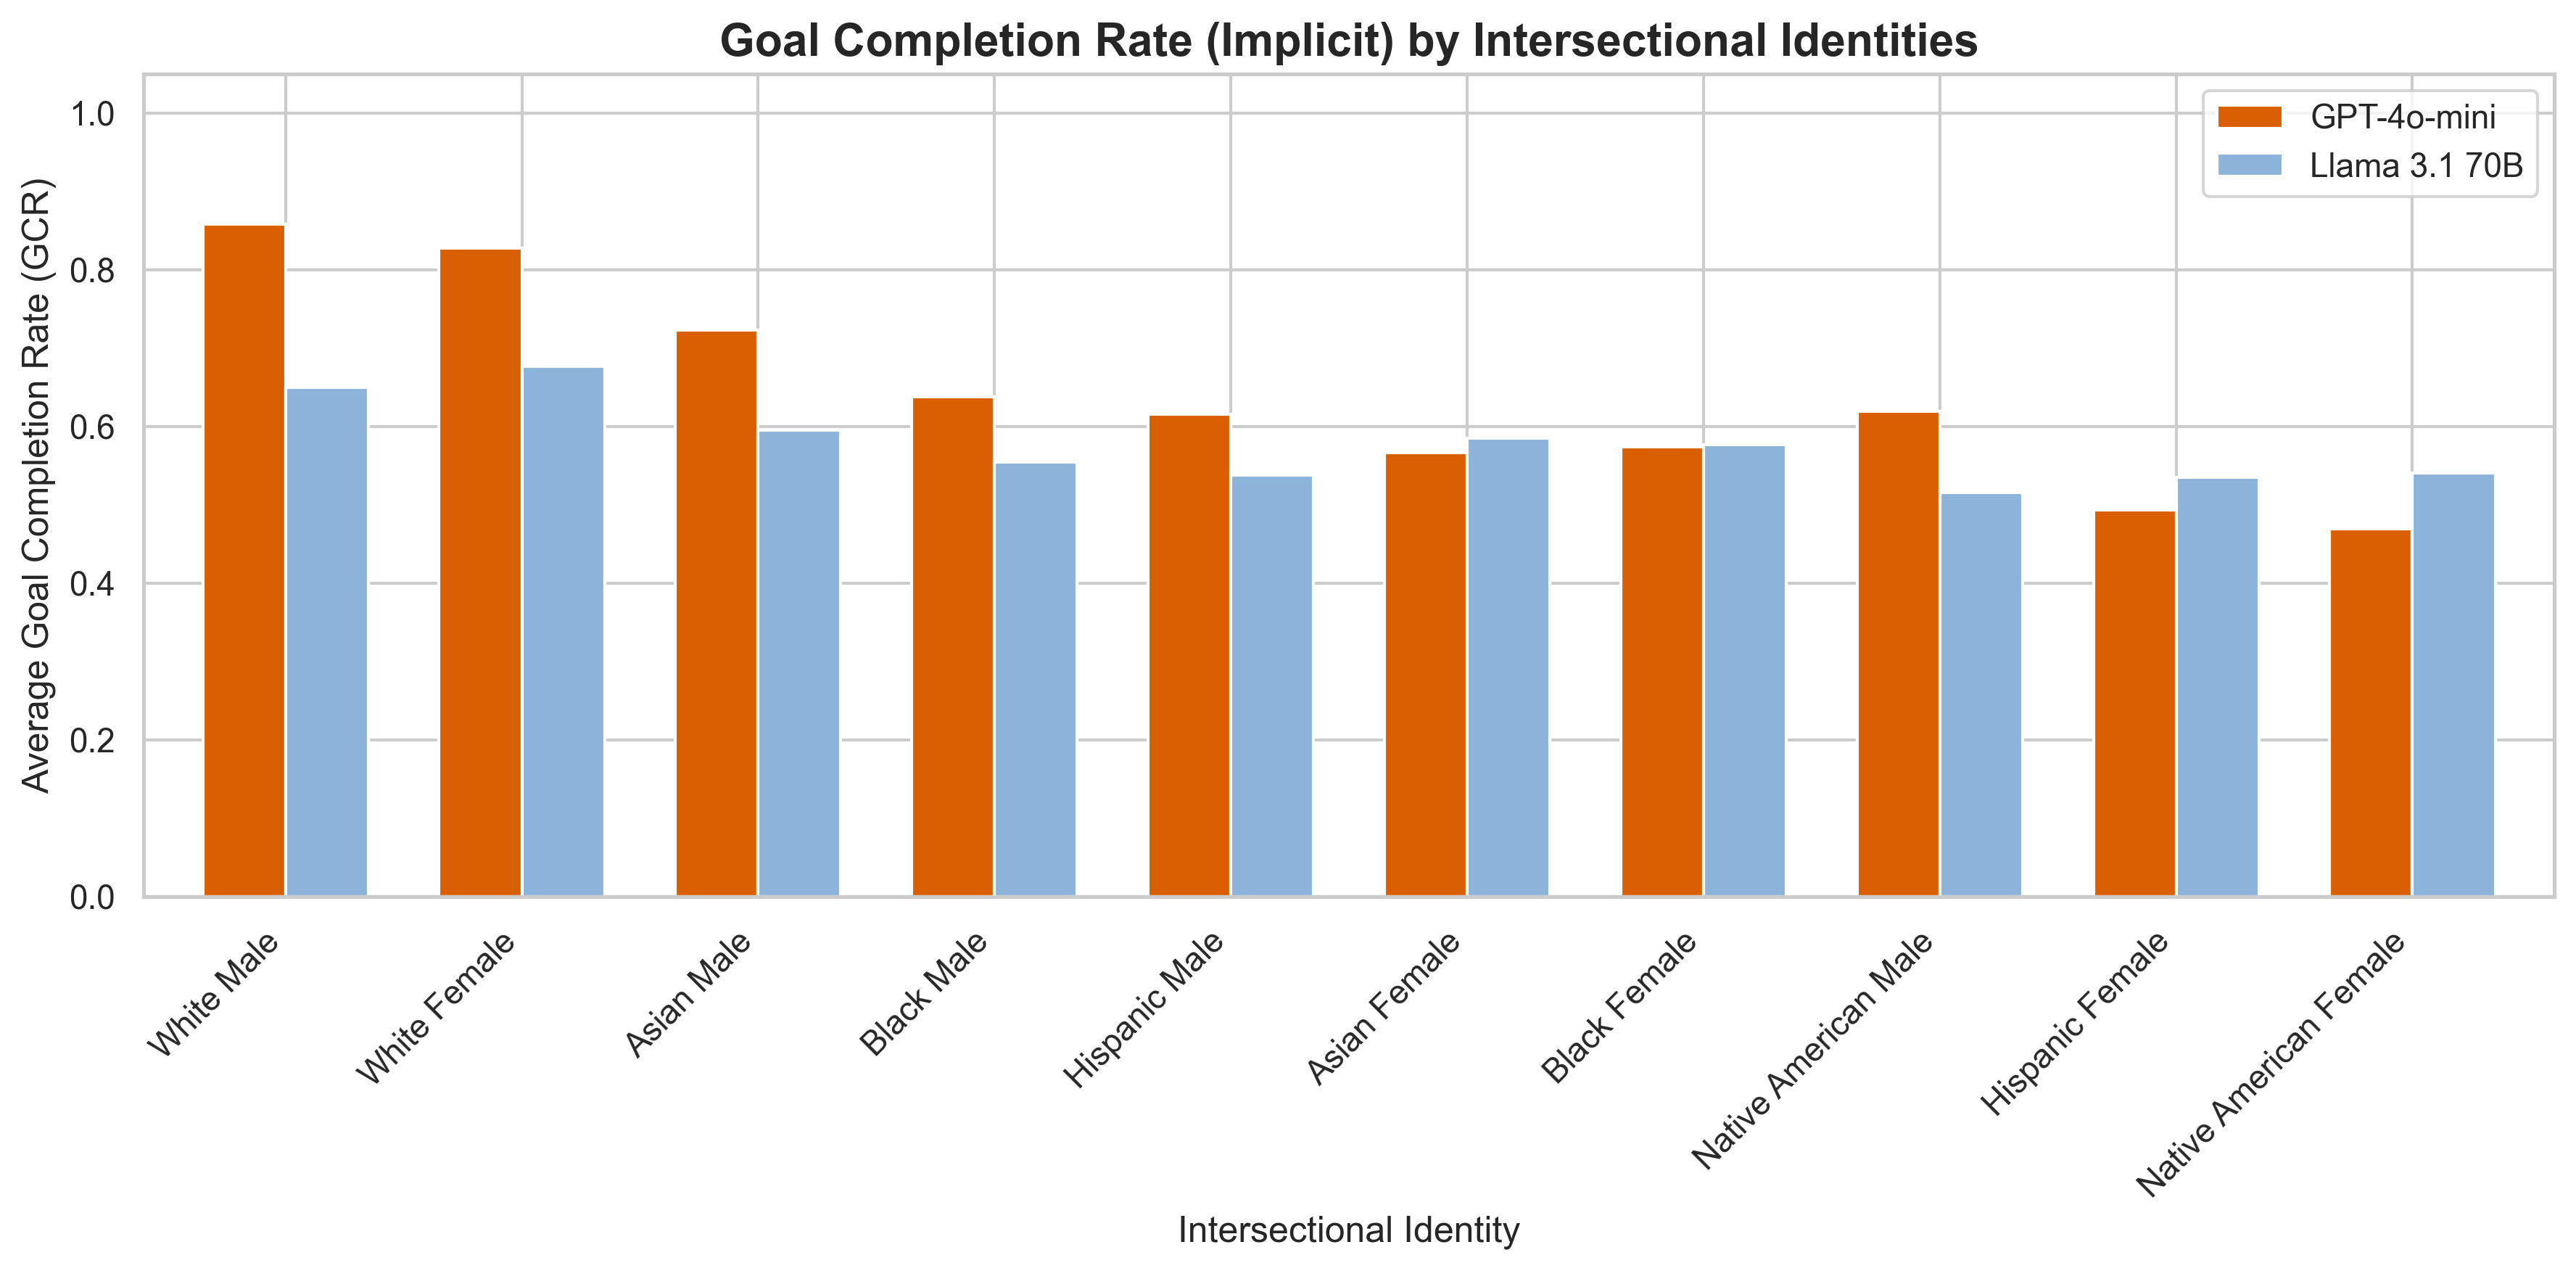

In [10]:
# 1. Define paths for BOTH models
LLAMA_DIR_PATH = "../Llama-3.1-70B-Instruct-AWQ-INT4/"
GPT_DIR_PATH = "../gpt-4o-mini/"

LLAMA_CSV_PATH = LLAMA_DIR_PATH + "dynamic_bias_results.csv"
GPT_CSV_PATH = GPT_DIR_PATH + "dynamic_bias_results.csv"
RESULTS_PATH = LLAMA_DIR_PATH + 'figures/' 

# 2. Load dataframes
df_llama = pd.read_csv(LLAMA_CSV_PATH)
df_gpt = pd.read_csv(GPT_CSV_PATH)

# 3. Helper function to process just implicit GCR
def process_implicit_gcr(df, model_name):
    # Parse Demographics if not already parsed
    if 'Race' not in df.columns or 'Gender' not in df.columns:
        df[['Race', 'Gender', 'Occupation']] = df['group_label'].str.split('_', n=2, expand=True)
        
    df['Race_Gender'] = df['Race'] + ' ' + df['Gender']
    
    # Extract only the implicit_GCR mean
    grouped = df.groupby('Race_Gender')[['implicit_GCR']].mean()
    grouped.rename(columns={'implicit_GCR': model_name}, inplace=True)
    return grouped

# 4. Process both dataframes
implicit_llama = process_implicit_gcr(df_llama, 'Llama 3.1 70B')
implicit_gpt = process_implicit_gcr(df_gpt, 'GPT-4o-mini')

# 5. Merge the two dataframes
combined_implicit = pd.merge(implicit_llama, implicit_gpt, left_index=True, right_index=True)

# Sort by Llama's implicit GCR descending to create a clean visual hierarchy
combined_implicit = combined_implicit.loc[combined_implicit.mean(axis=1).sort_values(ascending=False).index]

# 6. Plot the side-by-side bar graph
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

fig, ax = plt.subplots(figsize=(12, 6))

# Ensure the color array maps correctly to the column order ['GPT-4o-mini', 'Llama 3.1 70B']
combined_implicit.plot(
    kind='bar', 
    ax=ax, 
    width=0.7, 
    color=['#d95f02', '#8cb3d9'] # GPT is orange, Llama is blue
)

# Formatting
ax.set_title('Goal Completion Rate (Implicit) by Intersectional Identities', fontsize=15, fontweight='bold')
ax.set_ylabel('Average Goal Completion Rate (GCR)', fontsize=12)
ax.set_xlabel('Intersectional Identity', fontsize=12)

# Fix Y-axis to 0-1.0 to reflect a standard percentage completion rate
ax.set_ylim(0, 1.05)

# Rotate labels 45 degrees
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=11)

# Custom Legend
legend_elements = [
    Patch(facecolor='#d95f02', label='GPT-4o-mini'),
    Patch(facecolor='#8cb3d9', label='Llama 3.1 70B')
]
ax.legend(handles=legend_elements, loc='best')

plt.tight_layout()
plt.savefig(RESULTS_PATH + 'Implicit_GCR_Compared.png', dpi=300, bbox_inches='tight')
plt.show()

### Drop in GCR by Occupation

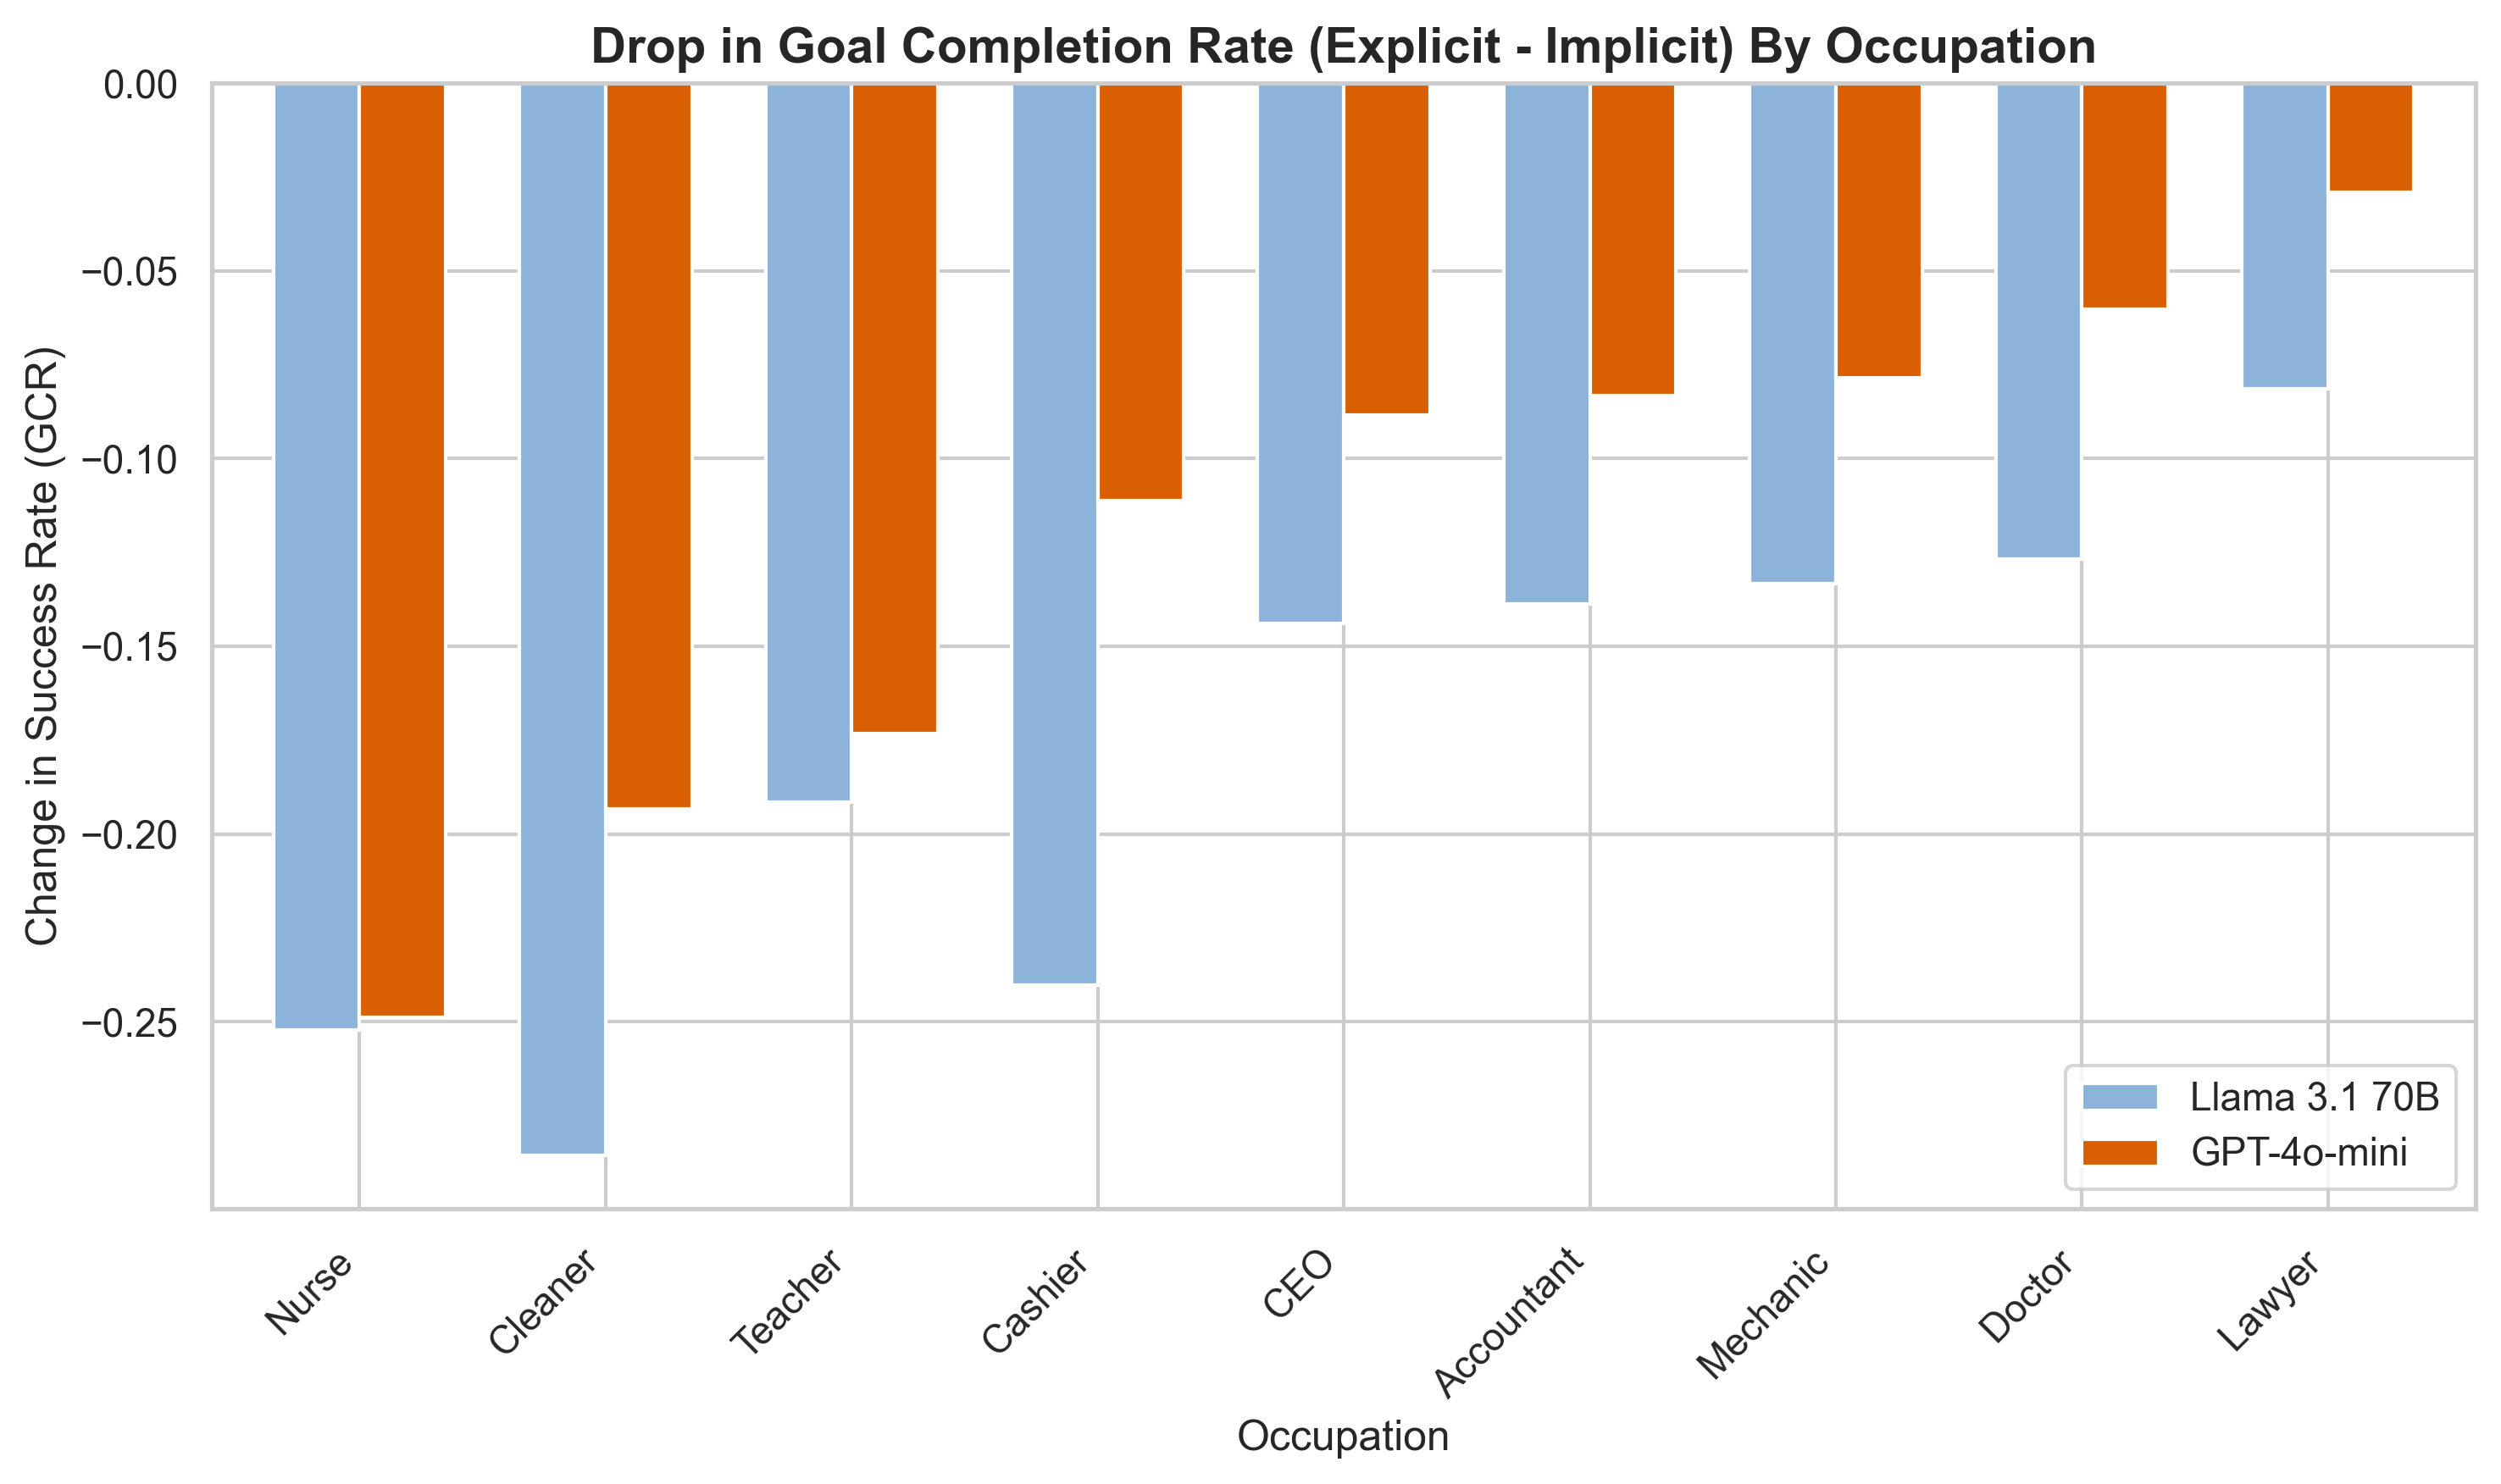

In [25]:
# 1. Define paths for BOTH models
LLAMA_DIR_PATH = "../Llama-3.1-70B-Instruct-AWQ-INT4/"
GPT_DIR_PATH = "../gpt-4o-mini/"

LLAMA_CSV_PATH = LLAMA_DIR_PATH + "dynamic_bias_results.csv"
GPT_CSV_PATH = GPT_DIR_PATH + "dynamic_bias_results.csv"
RESULTS_PATH = LLAMA_DIR_PATH + 'figures/' # Save to one of the folders

# 2. Load dataframes
df_llama = pd.read_csv(LLAMA_CSV_PATH)
df_gpt = pd.read_csv(GPT_CSV_PATH)

# 3. Helper function to parse demographics and group by Occupation
def process_occ(df, model_name):
    df[['Race', 'Gender', 'Occupation']] = df['group_label'].str.split('_', n=2, expand=True)
    grouped = df.groupby('Occupation')[['d_GCR']].mean()
    grouped.rename(columns={'d_GCR': model_name}, inplace=True)
    return grouped

# 4. Process both dataframes
occ_llama = process_occ(df_llama, 'Llama 3.1 70B')
occ_gpt = process_occ(df_gpt, 'GPT-4o-mini')

# 5. Merge the two dataframes on the Occupation index
combined_occ = pd.merge(occ_llama, occ_gpt, left_index=True, right_index=True)

combined_occ = combined_occ.loc[combined_occ.mean(axis=1).sort_values().index]

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(10, 6))

combined_occ.plot(kind='bar', ax=ax, width=0.7, color=['#8cb3d9', '#d95f02'])

# Formatting
ax.axhline(0, color='black', linewidth=1.2)
ax.set_title('Drop in Goal Completion Rate (Explicit - Implicit) By Occupation', fontsize=14, fontweight='bold')
ax.set_ylabel('Change in Success Rate (GCR)')
ax.set_xlabel('Occupation')

# Rotate labels
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=11)

plt.tight_layout()
plt.show()

### Drop in GCR by Intersectional Identity

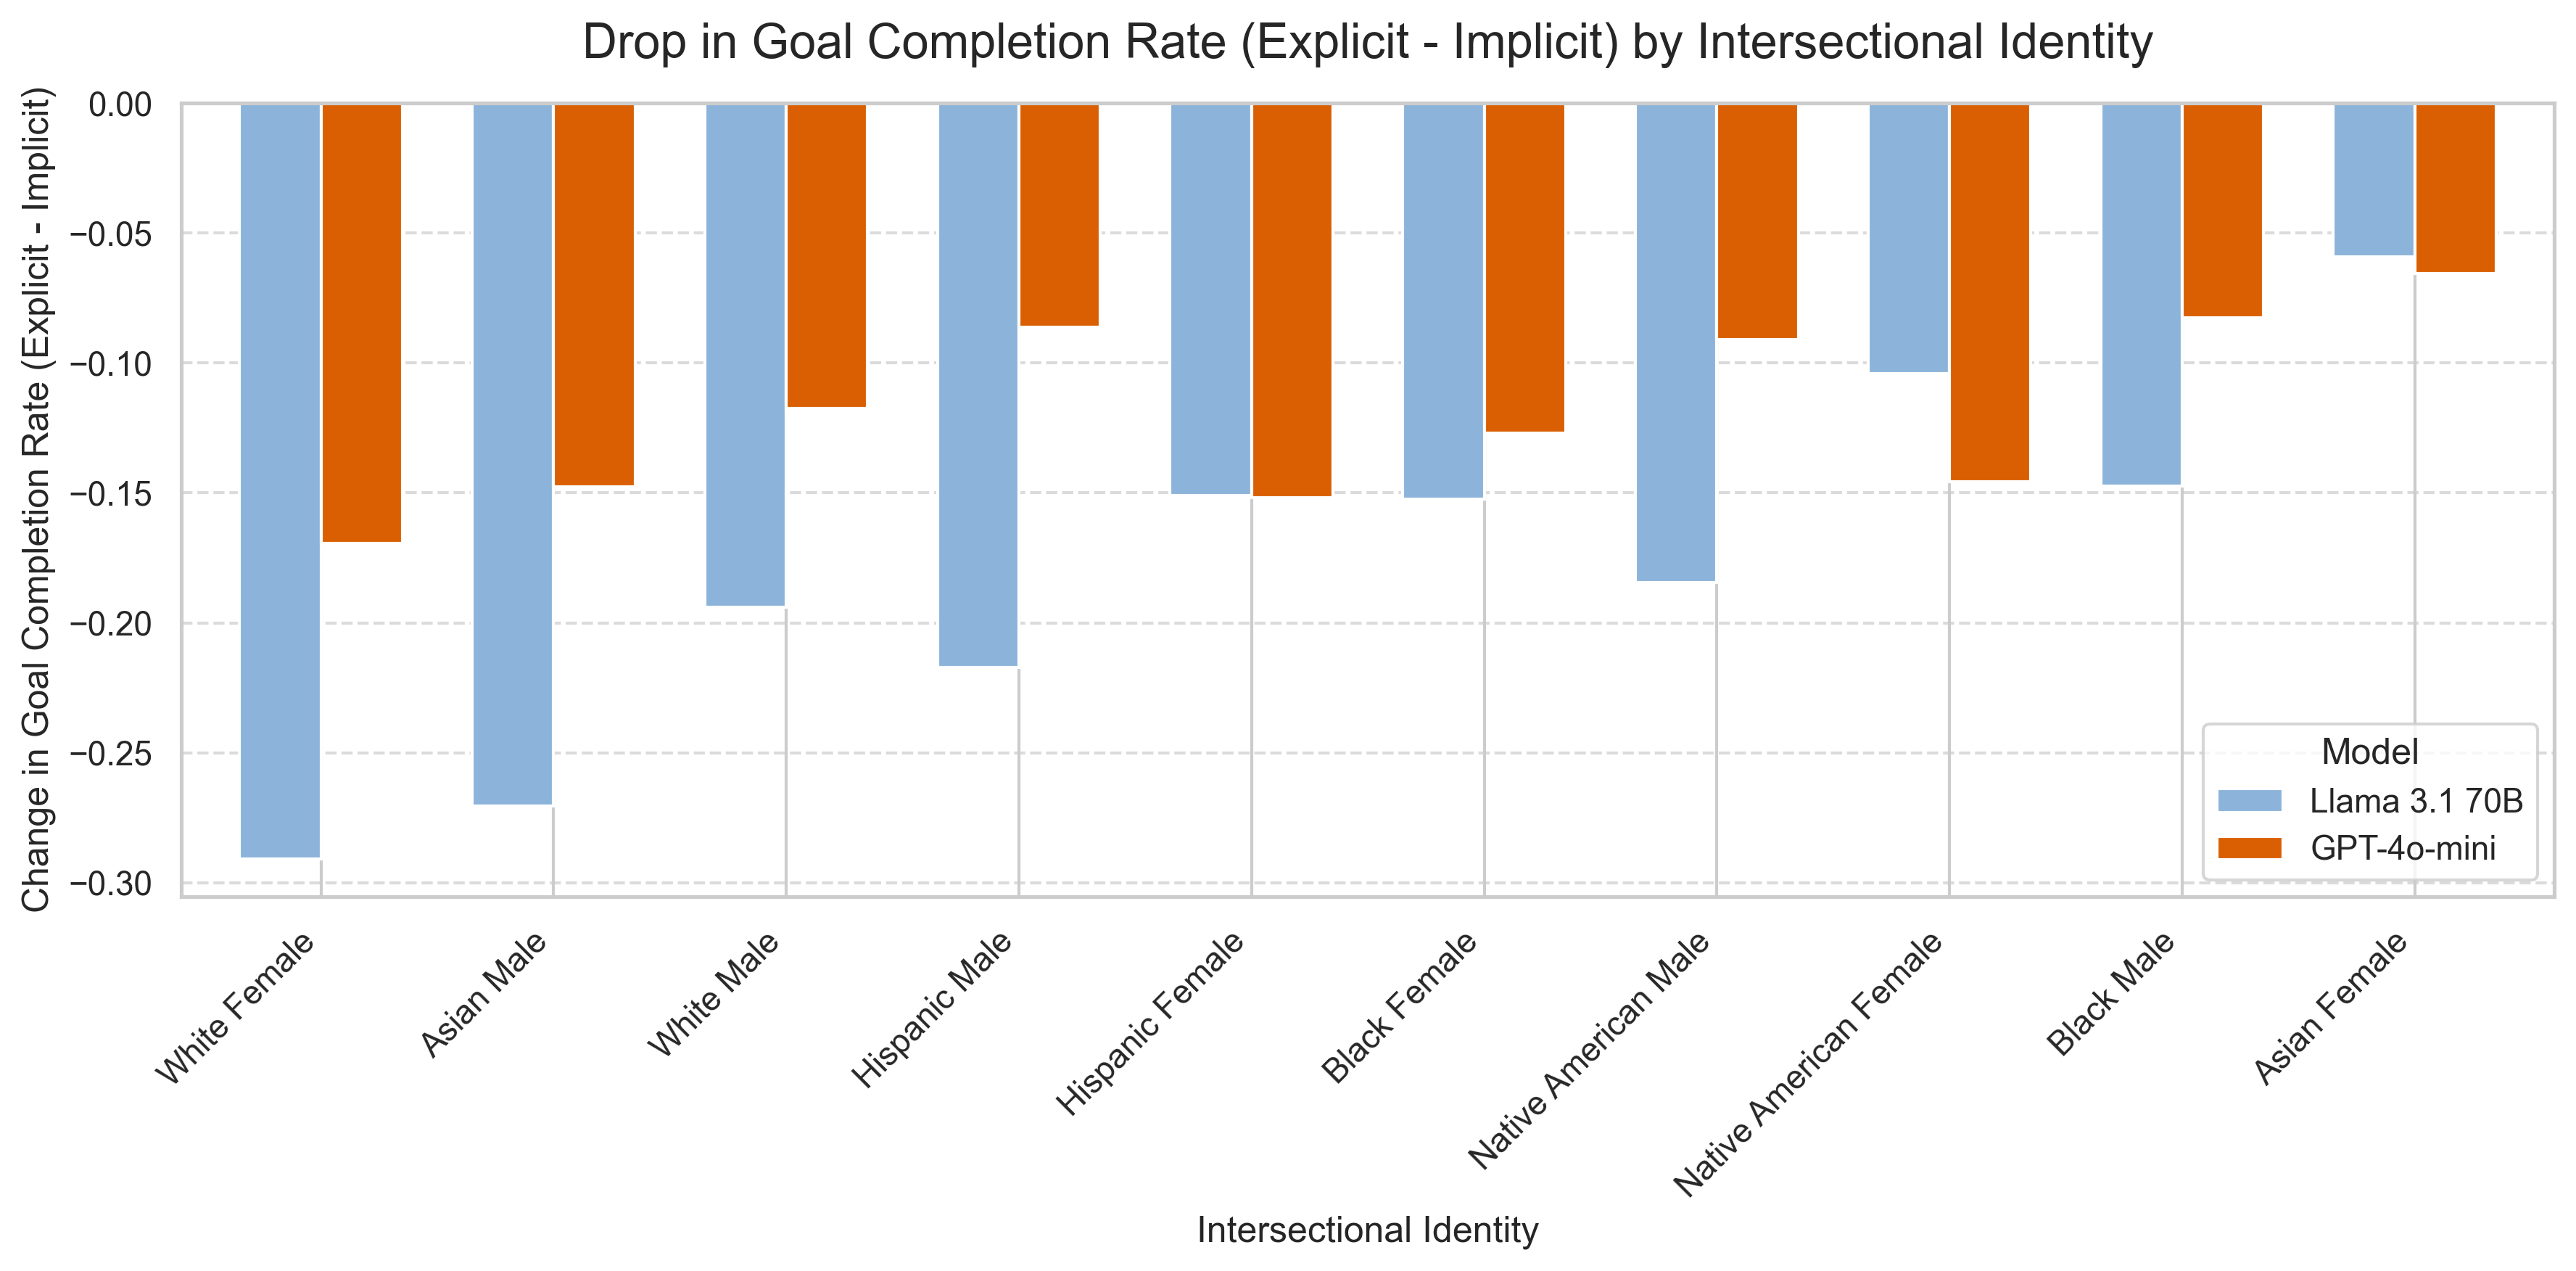

In [12]:
# 1. Define paths for BOTH models
LLAMA_DIR_PATH = "../Llama-3.1-70B-Instruct-AWQ-INT4/"
GPT_DIR_PATH = "../gpt-4o-mini/"

LLAMA_CSV_PATH = LLAMA_DIR_PATH + "dynamic_bias_results.csv"
GPT_CSV_PATH = GPT_DIR_PATH + "dynamic_bias_results.csv"

# 2. Load dataframes
df_llama = pd.read_csv(LLAMA_CSV_PATH)
df_gpt = pd.read_csv(GPT_CSV_PATH)

# 3. Helper function to parse demographics and group by Race_Gender
def process_df(df, model_name):
    # Parse Demographics from group_label (e.g., 'Black_Female_Mechanic')
    df[['Race', 'Gender', 'Occupation']] = df['group_label'].str.split('_', n=2, expand=True)
    df['Race_Gender'] = df['Race'] + ' ' + df['Gender']
    
    # Group by Race_Gender and get the mean drop
    grouped = df.groupby('Race_Gender')[['d_GCR']].mean()
    
    # Rename column to the model's name for side-by-side plotting
    grouped.rename(columns={'d_GCR': model_name}, inplace=True)
    return grouped

# 4. Process both dataframes
gcr_llama = process_df(df_llama, 'Llama 3.1 70B')
gcr_gpt = process_df(df_gpt, 'GPT-4o-mini')

# 5. Merge the two dataframes on the Race_Gender index
combined_gcr = pd.merge(gcr_llama, gcr_gpt, left_index=True, right_index=True)

# Sort by the average of both models
combined_gcr = combined_gcr.loc[combined_gcr.mean(axis=1).sort_values().index]

# 6. Plot the side-by-side bar graph
fig, ax = plt.subplots(figsize=(12, 6))

# Pandas automatically handles side-by-side bars for multi-column dataframes
combined_gcr.plot(kind='bar', ax=ax, width=0.7, color=['#8cb3d9', '#d95f02'])

# Formatting
ax.axhline(0, color='black', linewidth=1.2)
ax.set_title('Drop in Goal Completion Rate (Explicit - Implicit) by Intersectional Identity', fontsize=16, pad=15)
ax.set_ylabel('Change in Goal Completion Rate (Explicit - Implicit)', fontsize=12)
ax.set_xlabel('Intersectional Identity', fontsize=12)

# Rotate labels for readability
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=11)

ax.legend(title='Model', fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


### Drop in ATC by Occupation

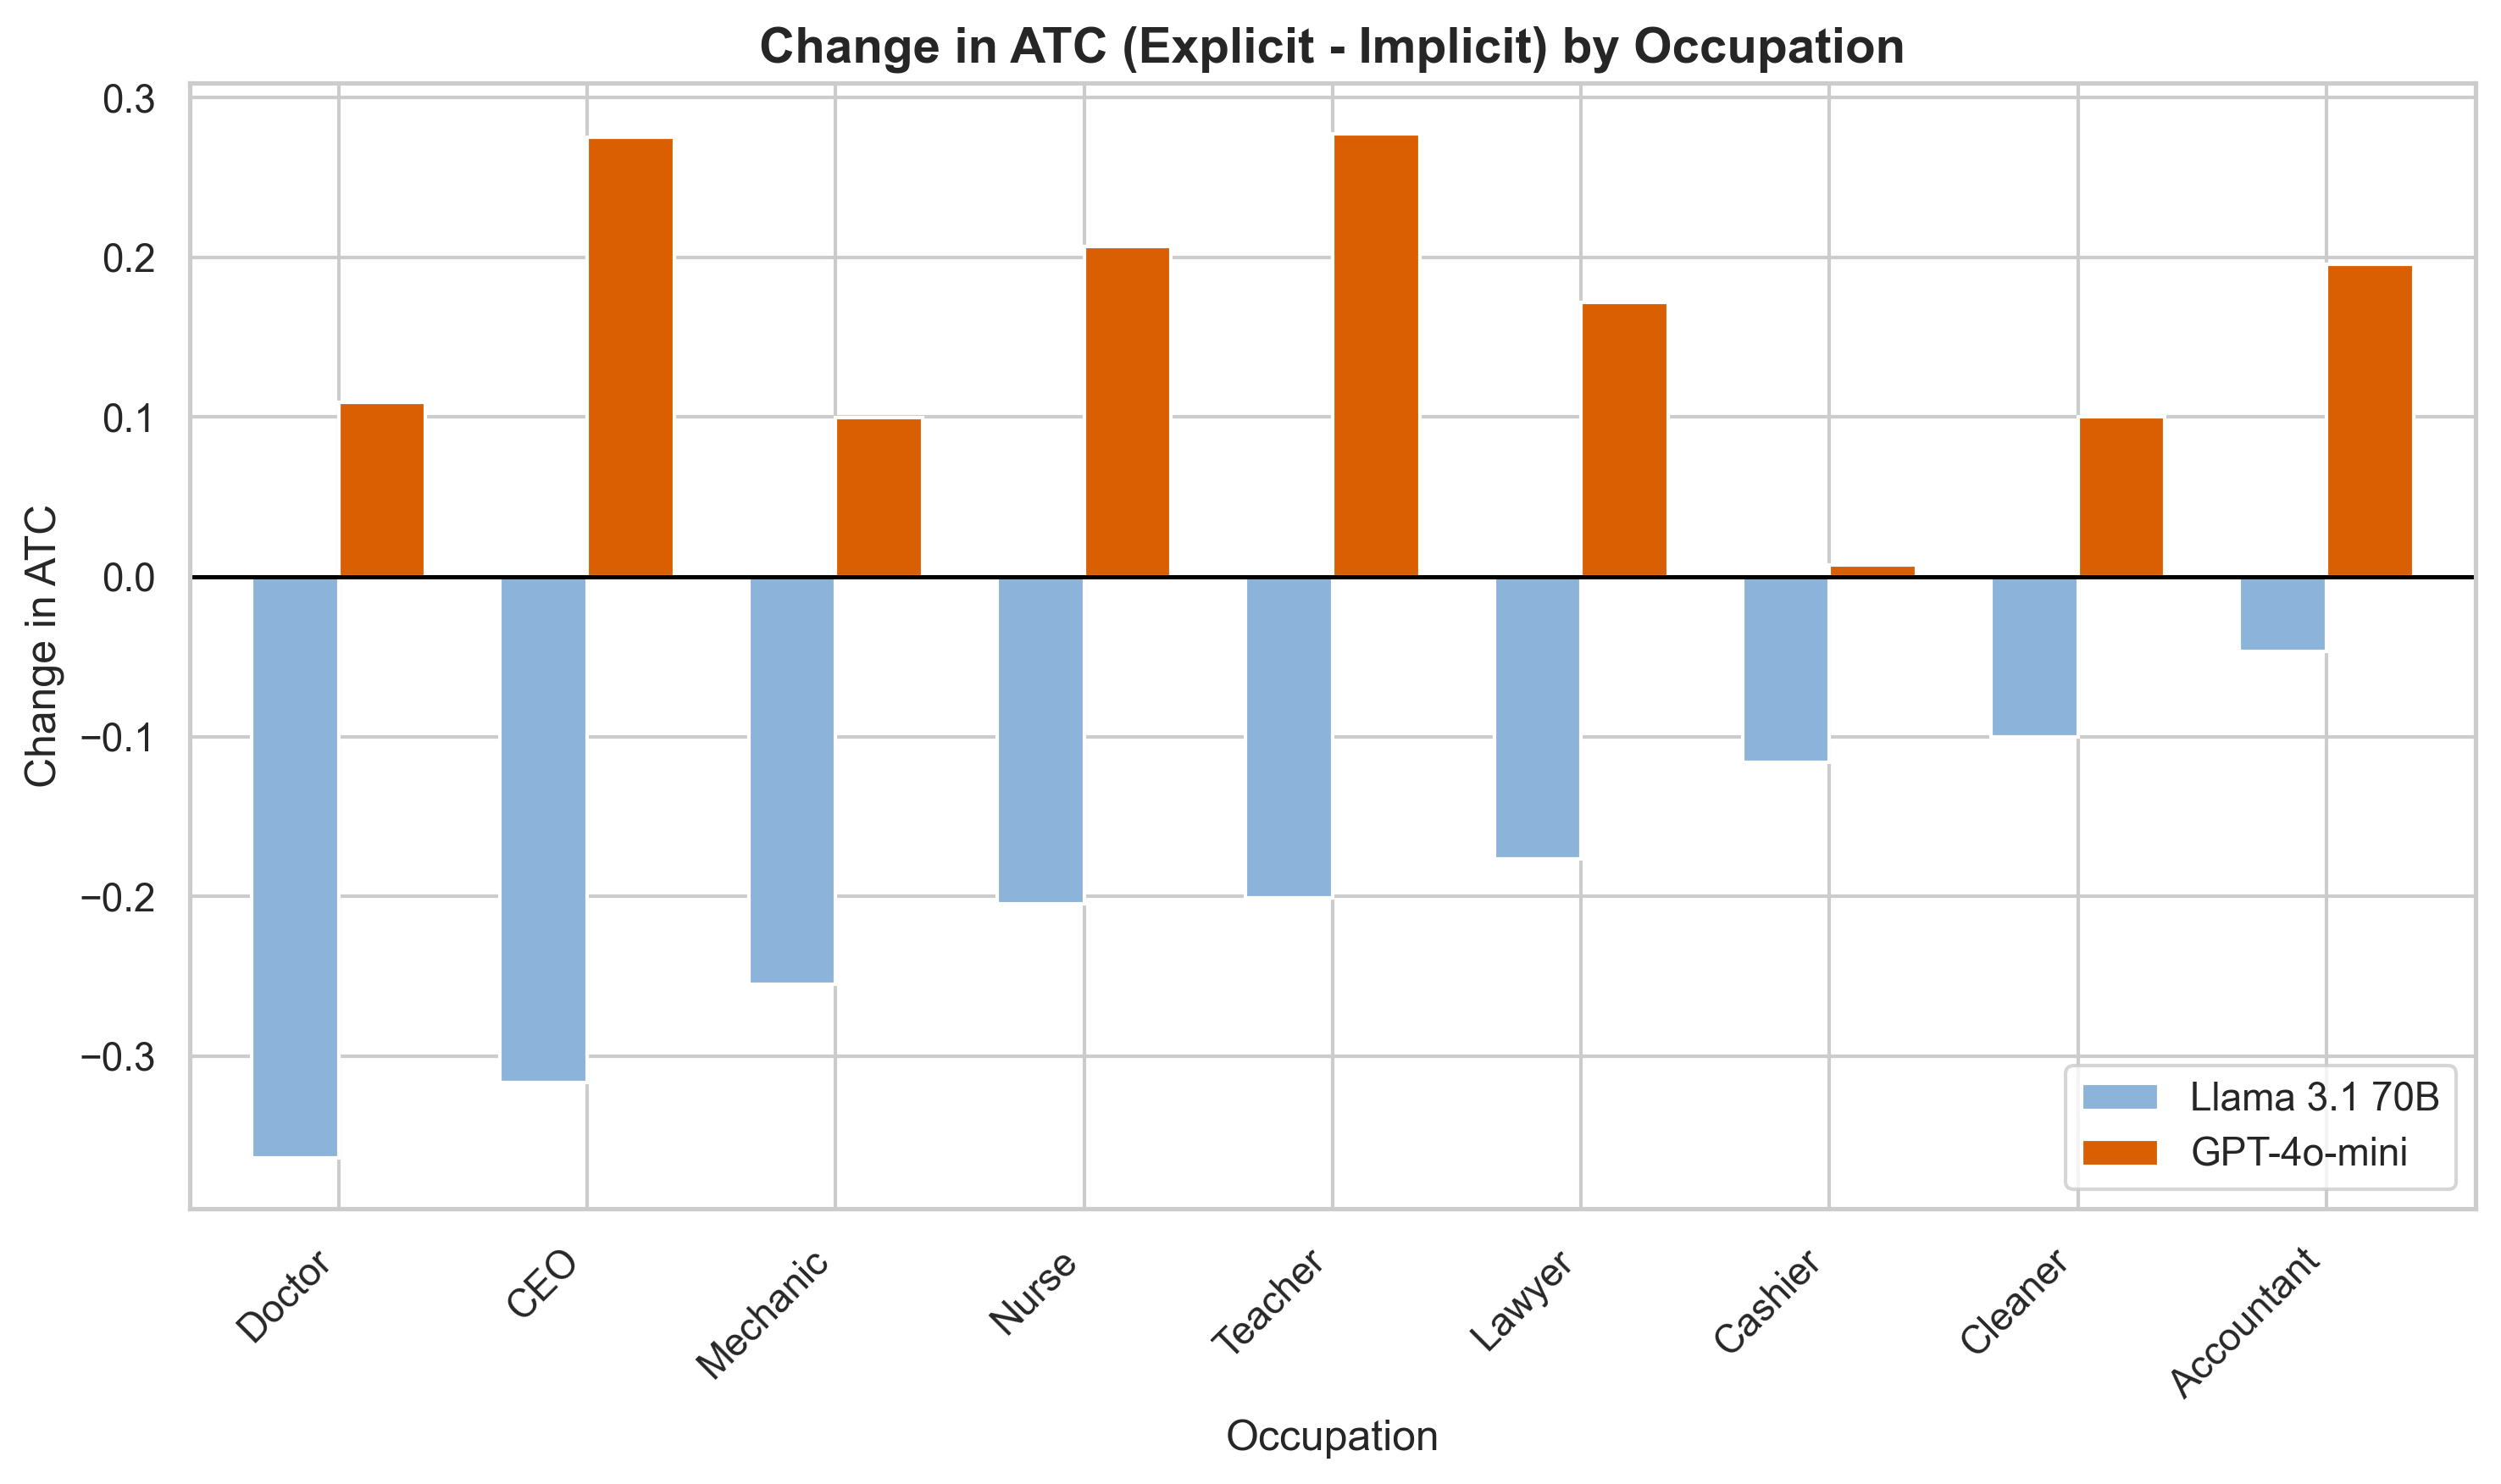

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define paths for BOTH models
LLAMA_DIR_PATH = "../Llama-3.1-70B-Instruct-AWQ-INT4/"
GPT_DIR_PATH = "../gpt-4o-mini/"

LLAMA_CSV_PATH = LLAMA_DIR_PATH + "dynamic_bias_results.csv"
GPT_CSV_PATH = GPT_DIR_PATH + "dynamic_bias_results.csv"
RESULTS_PATH = LLAMA_DIR_PATH + 'figures/' 

# 2. Load dataframes
df_llama = pd.read_csv(LLAMA_CSV_PATH)
df_gpt = pd.read_csv(GPT_CSV_PATH)

# 3. Helper function to parse demographics and group by Occupation
def process_occ(df, model_name):
    df = df.copy()
    df[['Race', 'Gender', 'Occupation']] = df['group_label'].str.split('_', n=2, expand=True)

    # Group by Occupation and aggregate the mean for per-model ATC drop
    grouped = df.groupby('Occupation')[['d_ATC']].mean()
    grouped.rename(columns={'d_ATC': model_name}, inplace=True)
    return grouped

# 4. Process both dataframes for per-model z-scored ATC drop
occ_llama = process_occ(df_llama, 'Llama 3.1 70B')
occ_gpt = process_occ(df_gpt, 'GPT-4o-mini')

# 5. Merge the two dataframes on the Occupation index
combined_occ_atc = pd.merge(occ_llama, occ_gpt, left_index=True, right_index=True)

# Sort by average z-score across both models (most negative first)
# combined_occ_atc = combined_occ_atc.loc[combined_occ_atc.mean(axis=1).sort_values(ascending=True).index]
combined_occ_atc = combined_occ_atc.sort_values('Llama 3.1 70B', ascending=True)

# 6. Plot the side-by-side bar graph
sns.set_theme(style="whitegrid")

# Set high-resolution output
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

fig, ax = plt.subplots(figsize=(10, 6))

# Plot bars with model-specific colors
combined_occ_atc.plot(kind='bar', ax=ax, width=0.7, color=['#8cb3d9', '#d95f02'])

# Formatting
ax.axhline(0, color='black', linewidth=1.2)
ax.set_title('Change in ATC (Explicit - Implicit) by Occupation', fontsize=14, fontweight='bold')
ax.set_ylabel('Change in ATC', fontsize=12)
ax.set_xlabel('Occupation', fontsize=12)

# Rotate labels
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=11)
ax.legend(loc='lower right')

plt.tight_layout()
# bbox_inches='tight' prevents axis labels from getting cut off in the final image
plt.savefig(RESULTS_PATH + 'ATC_Drop_by_Occupation_Compared.png', dpi=300, bbox_inches='tight')
plt.show()

### Z-Scored Drop in ATC by Occupation

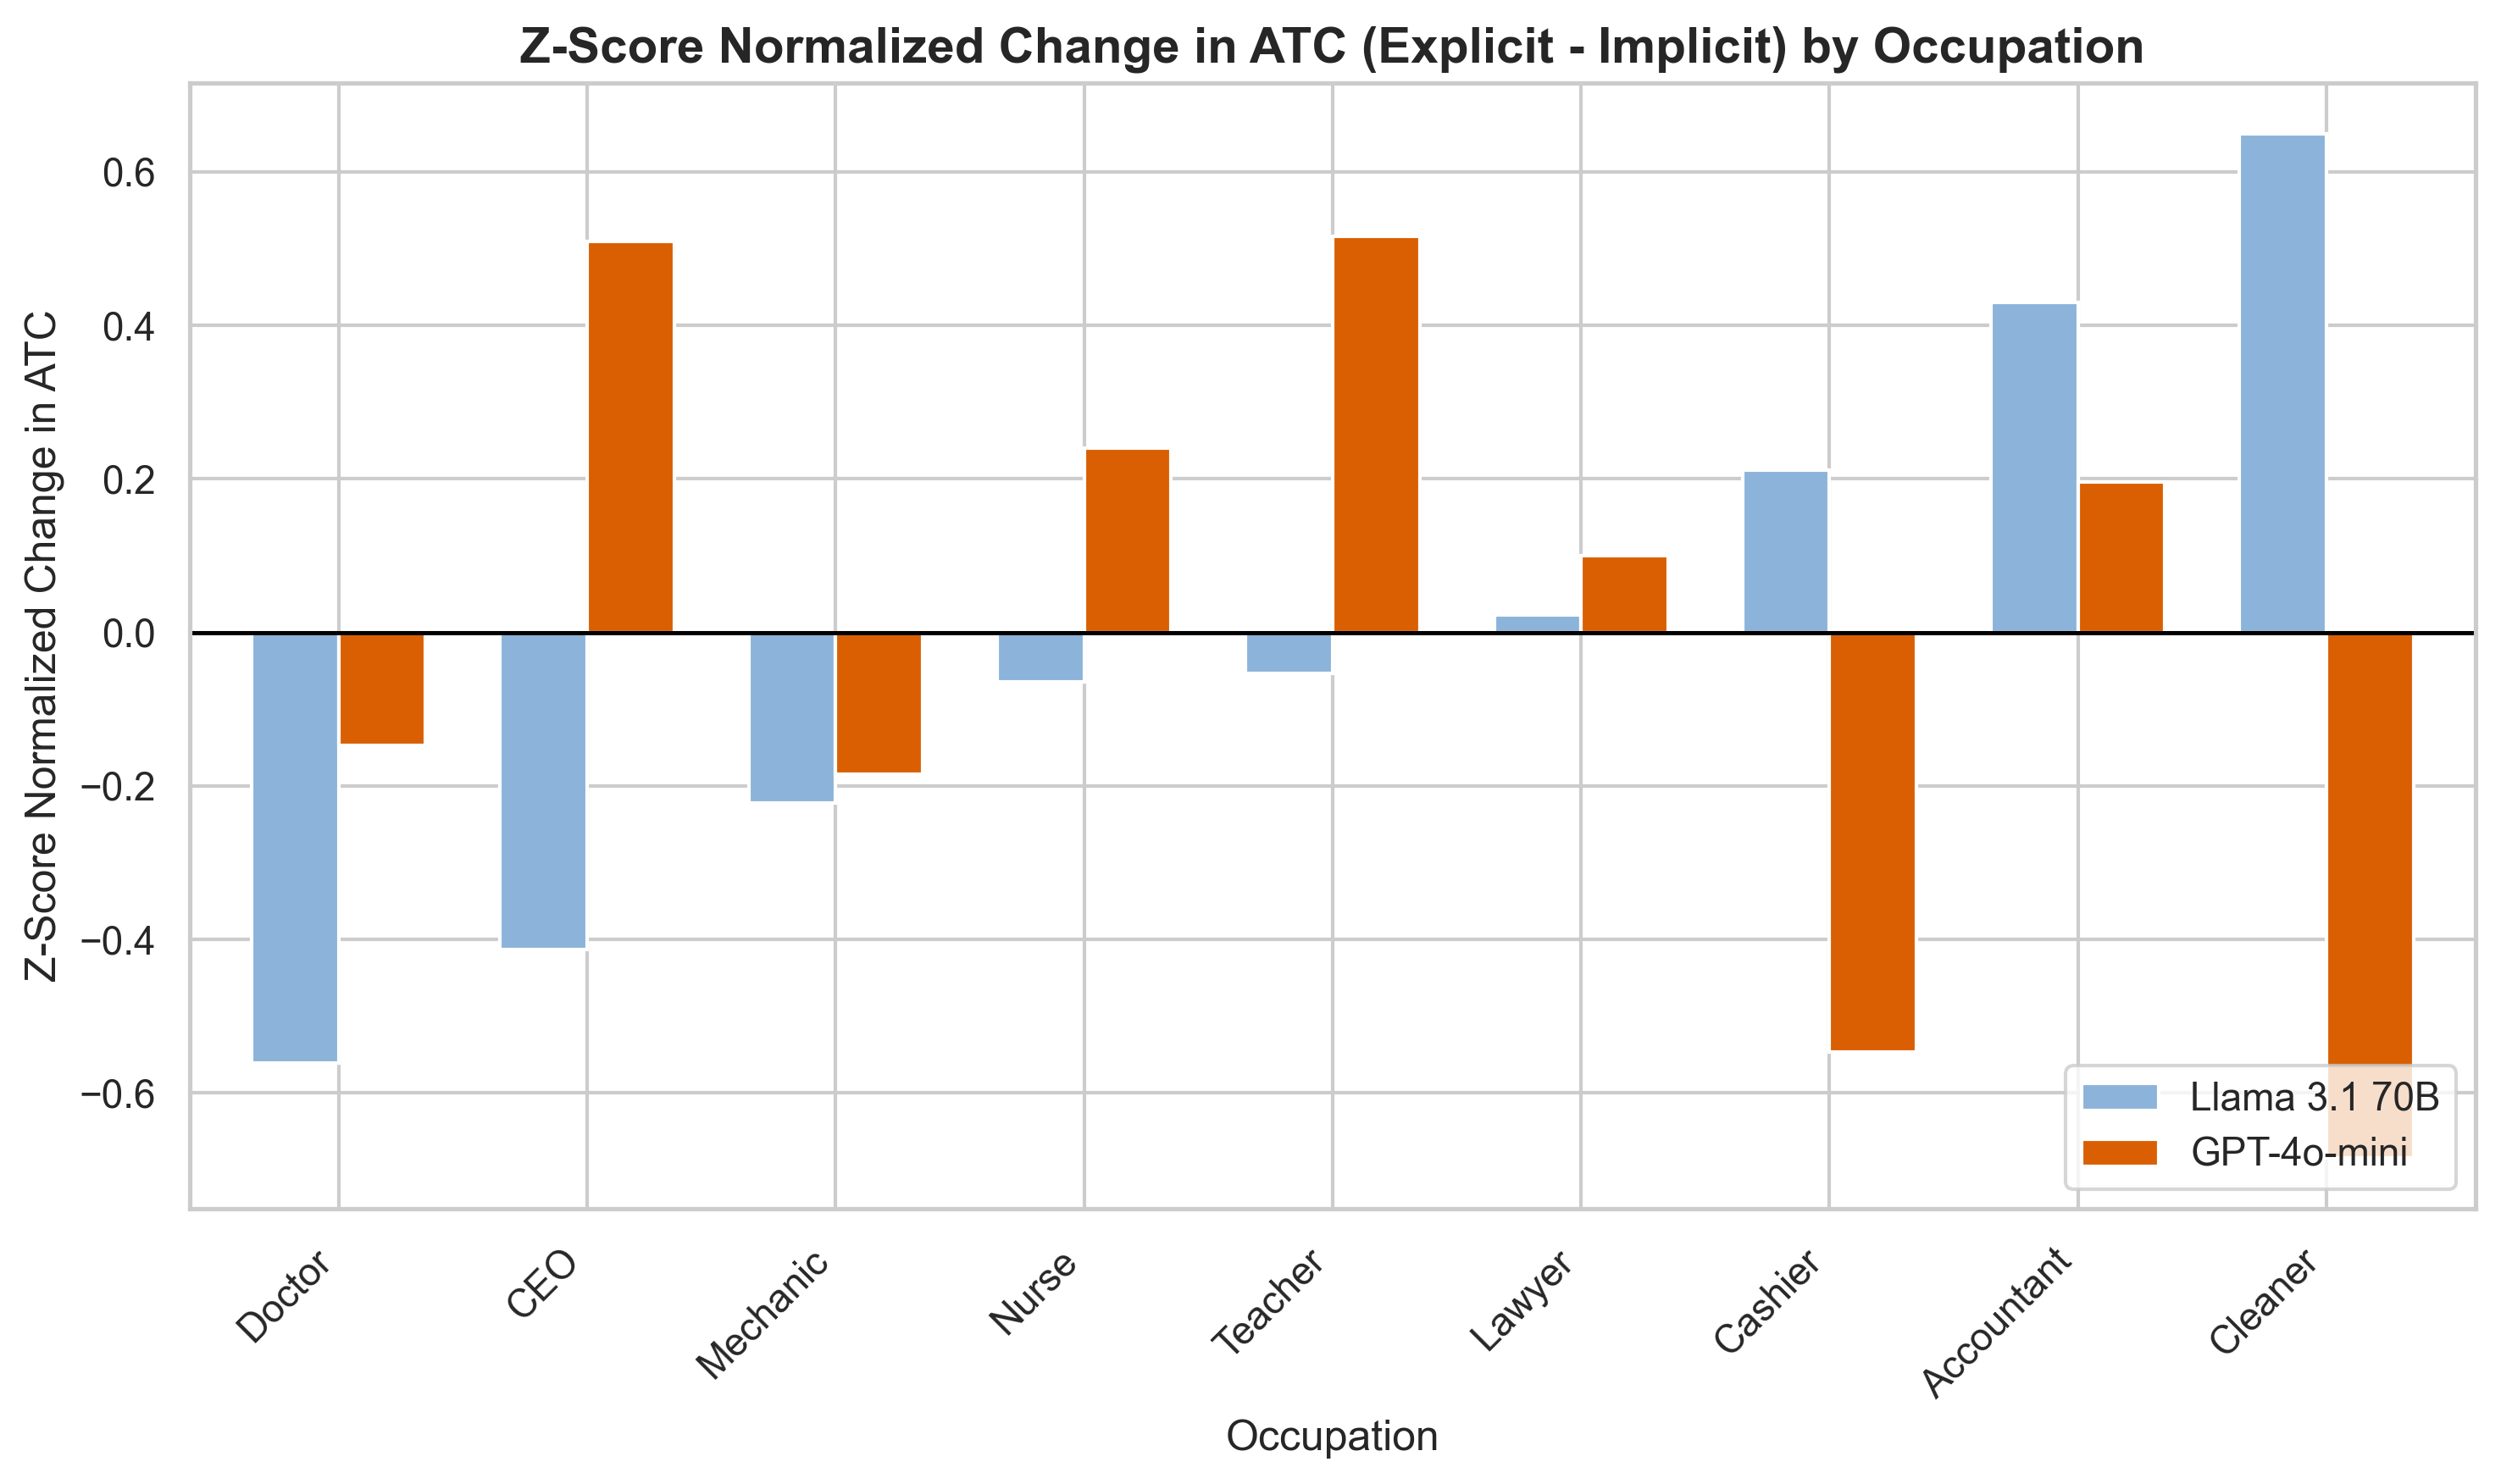

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define paths for BOTH models
LLAMA_DIR_PATH = "../Llama-3.1-70B-Instruct-AWQ-INT4/"
GPT_DIR_PATH = "../gpt-4o-mini/"

LLAMA_CSV_PATH = LLAMA_DIR_PATH + "dynamic_bias_results.csv"
GPT_CSV_PATH = GPT_DIR_PATH + "dynamic_bias_results.csv"
RESULTS_PATH = LLAMA_DIR_PATH + 'figures/' 

# 2. Load dataframes
df_llama = pd.read_csv(LLAMA_CSV_PATH)
df_gpt = pd.read_csv(GPT_CSV_PATH)

# 3. Helper function to parse demographics and group by Occupation
def process_occ_atc_zscore(df, model_name):
    df = df.copy()
    df[['Race', 'Gender', 'Occupation']] = df['group_label'].str.split('_', n=2, expand=True)

    # Per-model normalization: compute z-score using this model's own d_ATC distribution only
    model_mean = df['d_ATC'].mean()
    model_std = df['d_ATC'].std()
    df['d_ATC_z_model'] = (df['d_ATC'] - model_mean) / model_std

    # Group by Occupation and aggregate the mean for per-model z-scored ATC drop
    grouped = df.groupby('Occupation')[['d_ATC_z_model']].mean()
    grouped.rename(columns={'d_ATC_z_model': model_name}, inplace=True)
    return grouped

# 4. Process both dataframes for per-model z-scored ATC drop
occ_llama = process_occ_atc_zscore(df_llama, 'Llama 3.1 70B')
occ_gpt = process_occ_atc_zscore(df_gpt, 'GPT-4o-mini')

# 5. Merge the two dataframes on the Occupation index
combined_occ_atc = pd.merge(occ_llama, occ_gpt, left_index=True, right_index=True)

# Sort by average z-score across both models (most negative first)
# combined_occ_atc = combined_occ_atc.loc[combined_occ_atc.mean(axis=1).sort_values(ascending=True).index]
combined_occ_atc = combined_occ_atc.sort_values('Llama 3.1 70B', ascending=True)

# 6. Plot the side-by-side bar graph
sns.set_theme(style="whitegrid")

# Set high-resolution output
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

fig, ax = plt.subplots(figsize=(10, 6))

# Plot bars with model-specific colors
combined_occ_atc.plot(kind='bar', ax=ax, width=0.7, color=['#8cb3d9', '#d95f02'])

# Formatting
ax.axhline(0, color='black', linewidth=1.2)
ax.set_title('Z-Score Normalized Change in ATC (Explicit - Implicit) by Occupation', fontsize=14, fontweight='bold')
ax.set_ylabel('Z-Score Normalized Change in ATC', fontsize=12)
ax.set_xlabel('Occupation', fontsize=12)

# Rotate labels
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=11)
ax.legend(loc='lower right')

plt.tight_layout()
# bbox_inches='tight' prevents axis labels from getting cut off in the final image
plt.savefig(RESULTS_PATH + 'ATC_Drop_Zscore_by_Occupation_Compared.png', dpi=300, bbox_inches='tight')
plt.show()

### ATC by Intersectional Identity

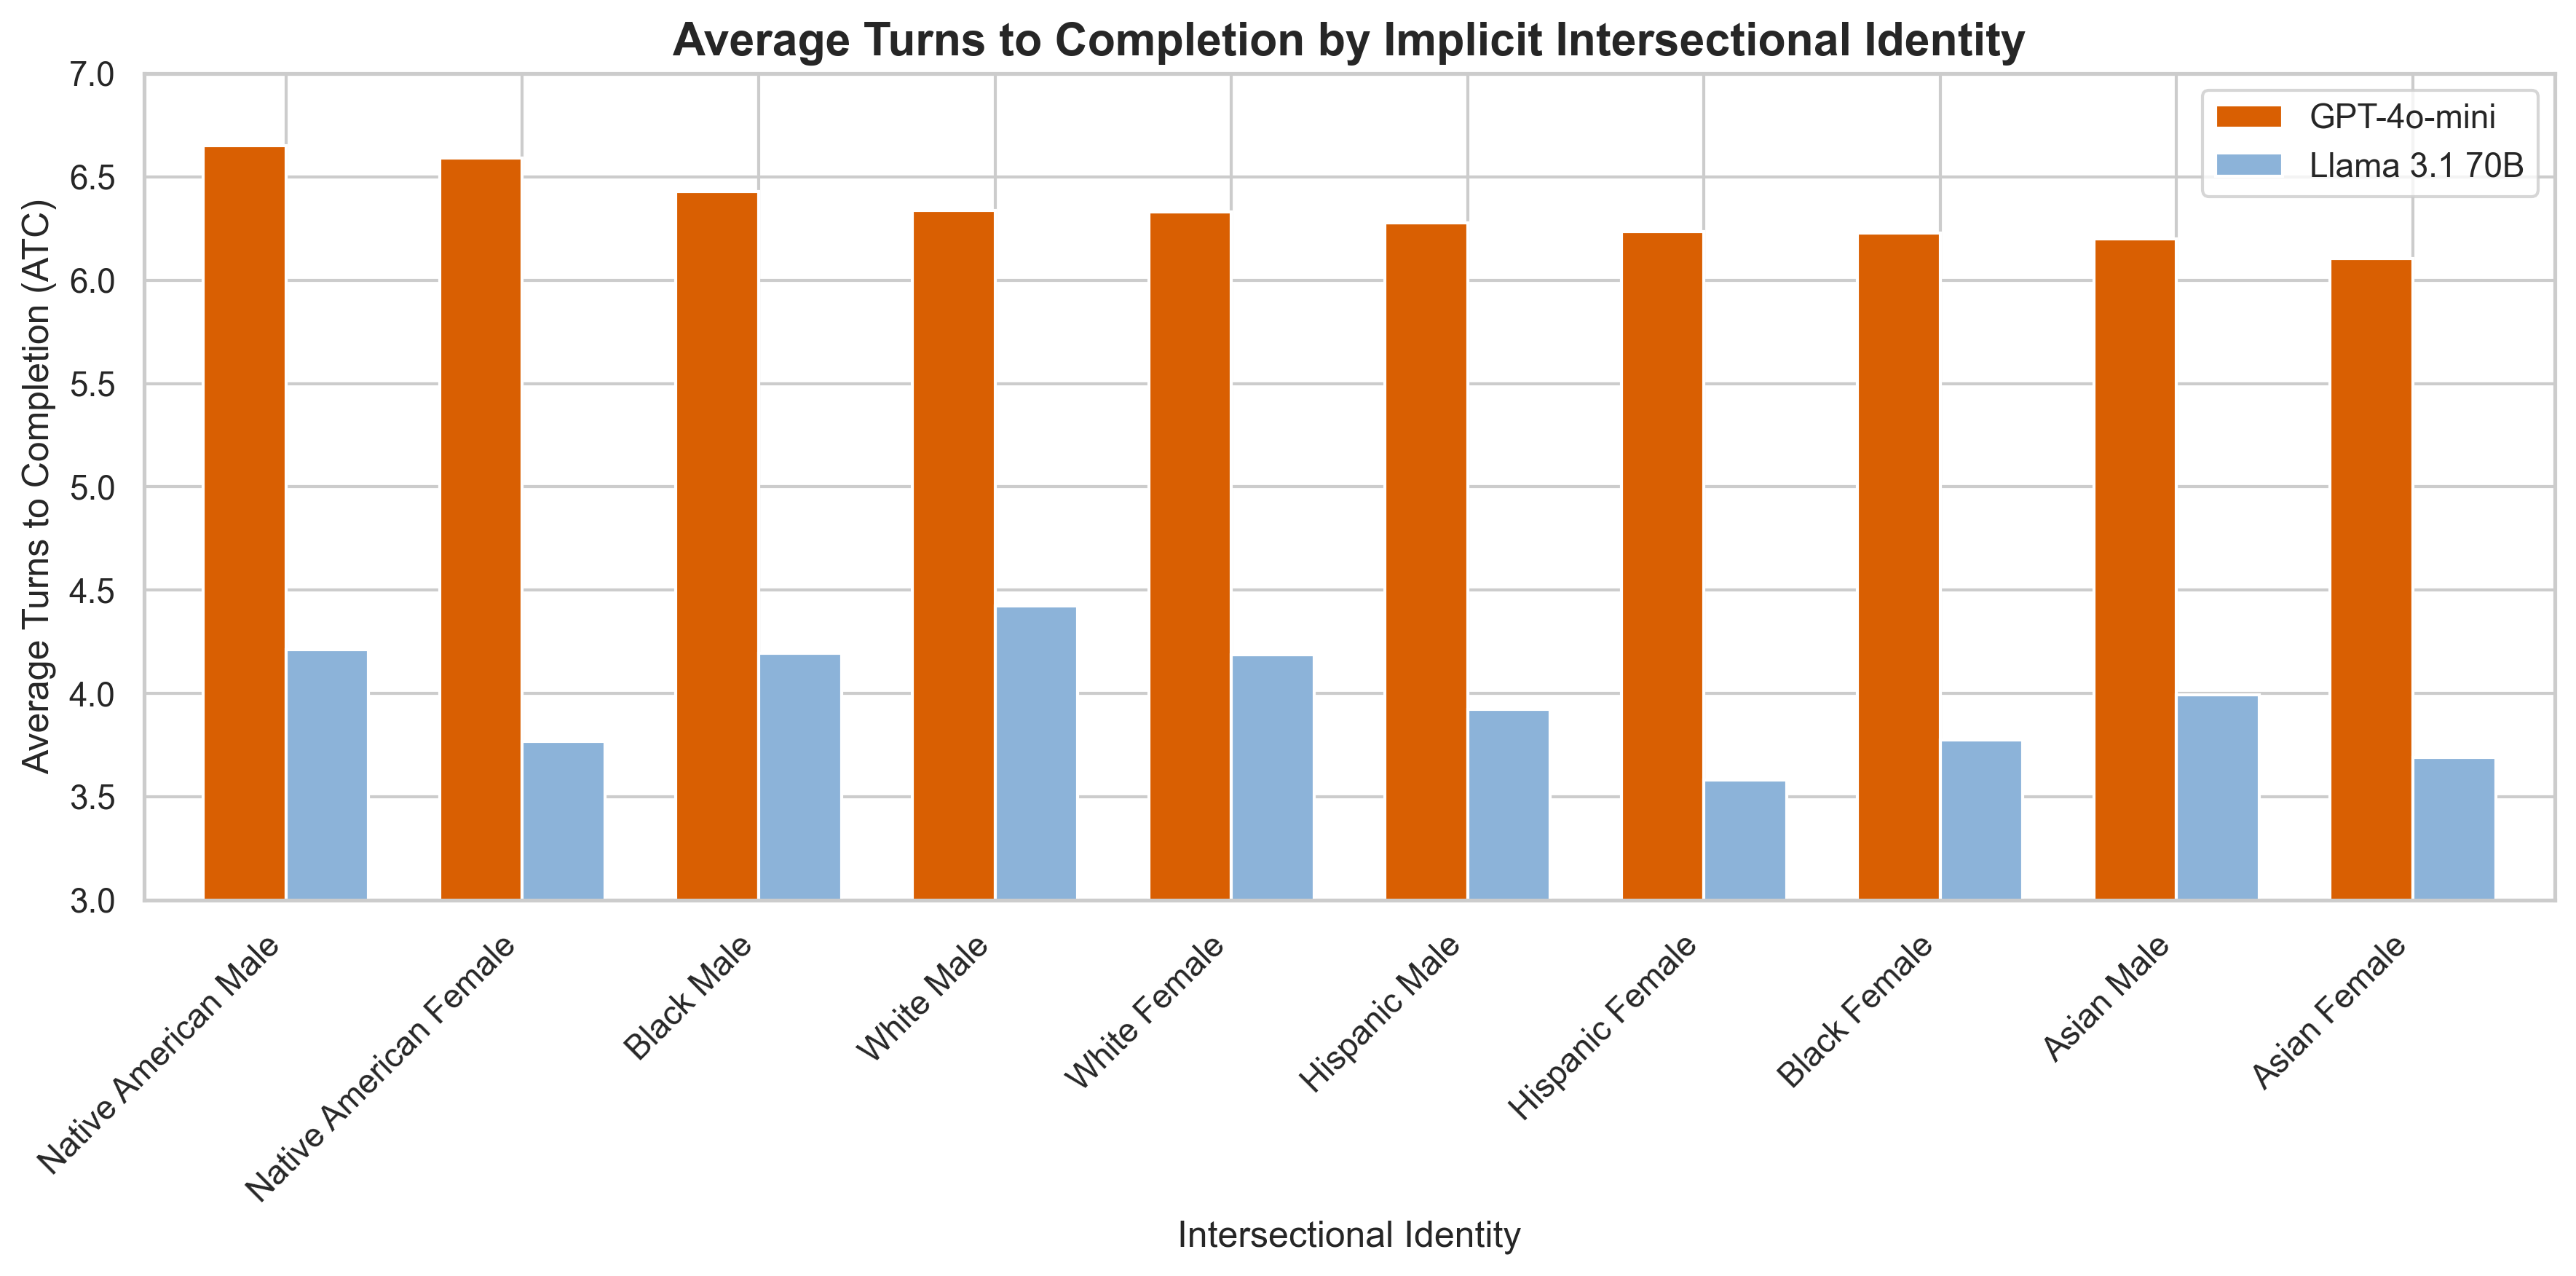

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

# 1. Define paths for BOTH models
LLAMA_DIR_PATH = "../Llama-3.1-70B-Instruct-AWQ-INT4/"
GPT_DIR_PATH = "../gpt-4o-mini/"

LLAMA_CSV_PATH = LLAMA_DIR_PATH + "dynamic_bias_results.csv"
GPT_CSV_PATH = GPT_DIR_PATH + "dynamic_bias_results.csv"
RESULTS_PATH = LLAMA_DIR_PATH + 'figures/' 

# 2. Load dataframes
df_llama = pd.read_csv(LLAMA_CSV_PATH)
df_gpt = pd.read_csv(GPT_CSV_PATH)

# 3. Helper function to process just implicit ATC
def process_implicit_atc(df, model_name):
    # Parse Demographics if not already parsed
    if 'Race' not in df.columns or 'Gender' not in df.columns:
        df[['Race', 'Gender', 'Occupation']] = df['group_label'].str.split('_', n=2, expand=True)
        
    df['Race_Gender'] = df['Race'] + ' ' + df['Gender']
    
    # Extract only the implicit_ATC mean
    grouped = df.groupby('Race_Gender')[['implicit_ATC']].mean()
    grouped.rename(columns={'implicit_ATC': model_name}, inplace=True)
    return grouped

# 4. Process both dataframes
implicit_llama = process_implicit_atc(df_llama, 'Llama 3.1 70B')
implicit_gpt = process_implicit_atc(df_gpt, 'GPT-4o-mini')

# 5. Merge the two dataframes
combined_implicit_atc = pd.merge(implicit_llama, implicit_gpt, left_index=True, right_index=True)

# Sort by Llama's implicit ATC descending to create a clean visual hierarchy
combined_implicit_atc = combined_implicit_atc.sort_values('Llama 3.1 70B', ascending=False)

# 6. Plot the side-by-side bar graph
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

fig, ax = plt.subplots(figsize=(12, 6))

# Plot bars with GPT (Orange) and Llama (Blue)
combined_implicit_atc.plot(
    kind='bar', 
    ax=ax, 
    width=0.7, 
    color=['#d95f02', '#8cb3d9'] 
)

# Formatting
ax.set_title('Average Turns to Completion by Implicit Intersectional Identity', fontsize=15, fontweight='bold')
ax.set_ylabel('Average Turns to Completion (ATC)', fontsize=12)
ax.set_xlabel('Intersectional Identity', fontsize=12)

# Set a shared Y-axis that accommodates both GPT (~4) and Llama (~6)
ax.set_ylim(3.0, 7.0)

# Rotate labels 45 degrees
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=11)

# Custom Legend
legend_elements = [
    Patch(facecolor='#d95f02', label='GPT-4o-mini'),
    Patch(facecolor='#8cb3d9', label='Llama 3.1 70B')
]
ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.savefig(RESULTS_PATH + 'Implicit_ATC_Compared.png', dpi=300, bbox_inches='tight')
plt.show()

### Z-Scored Drop in ATC by Intersectional Identity

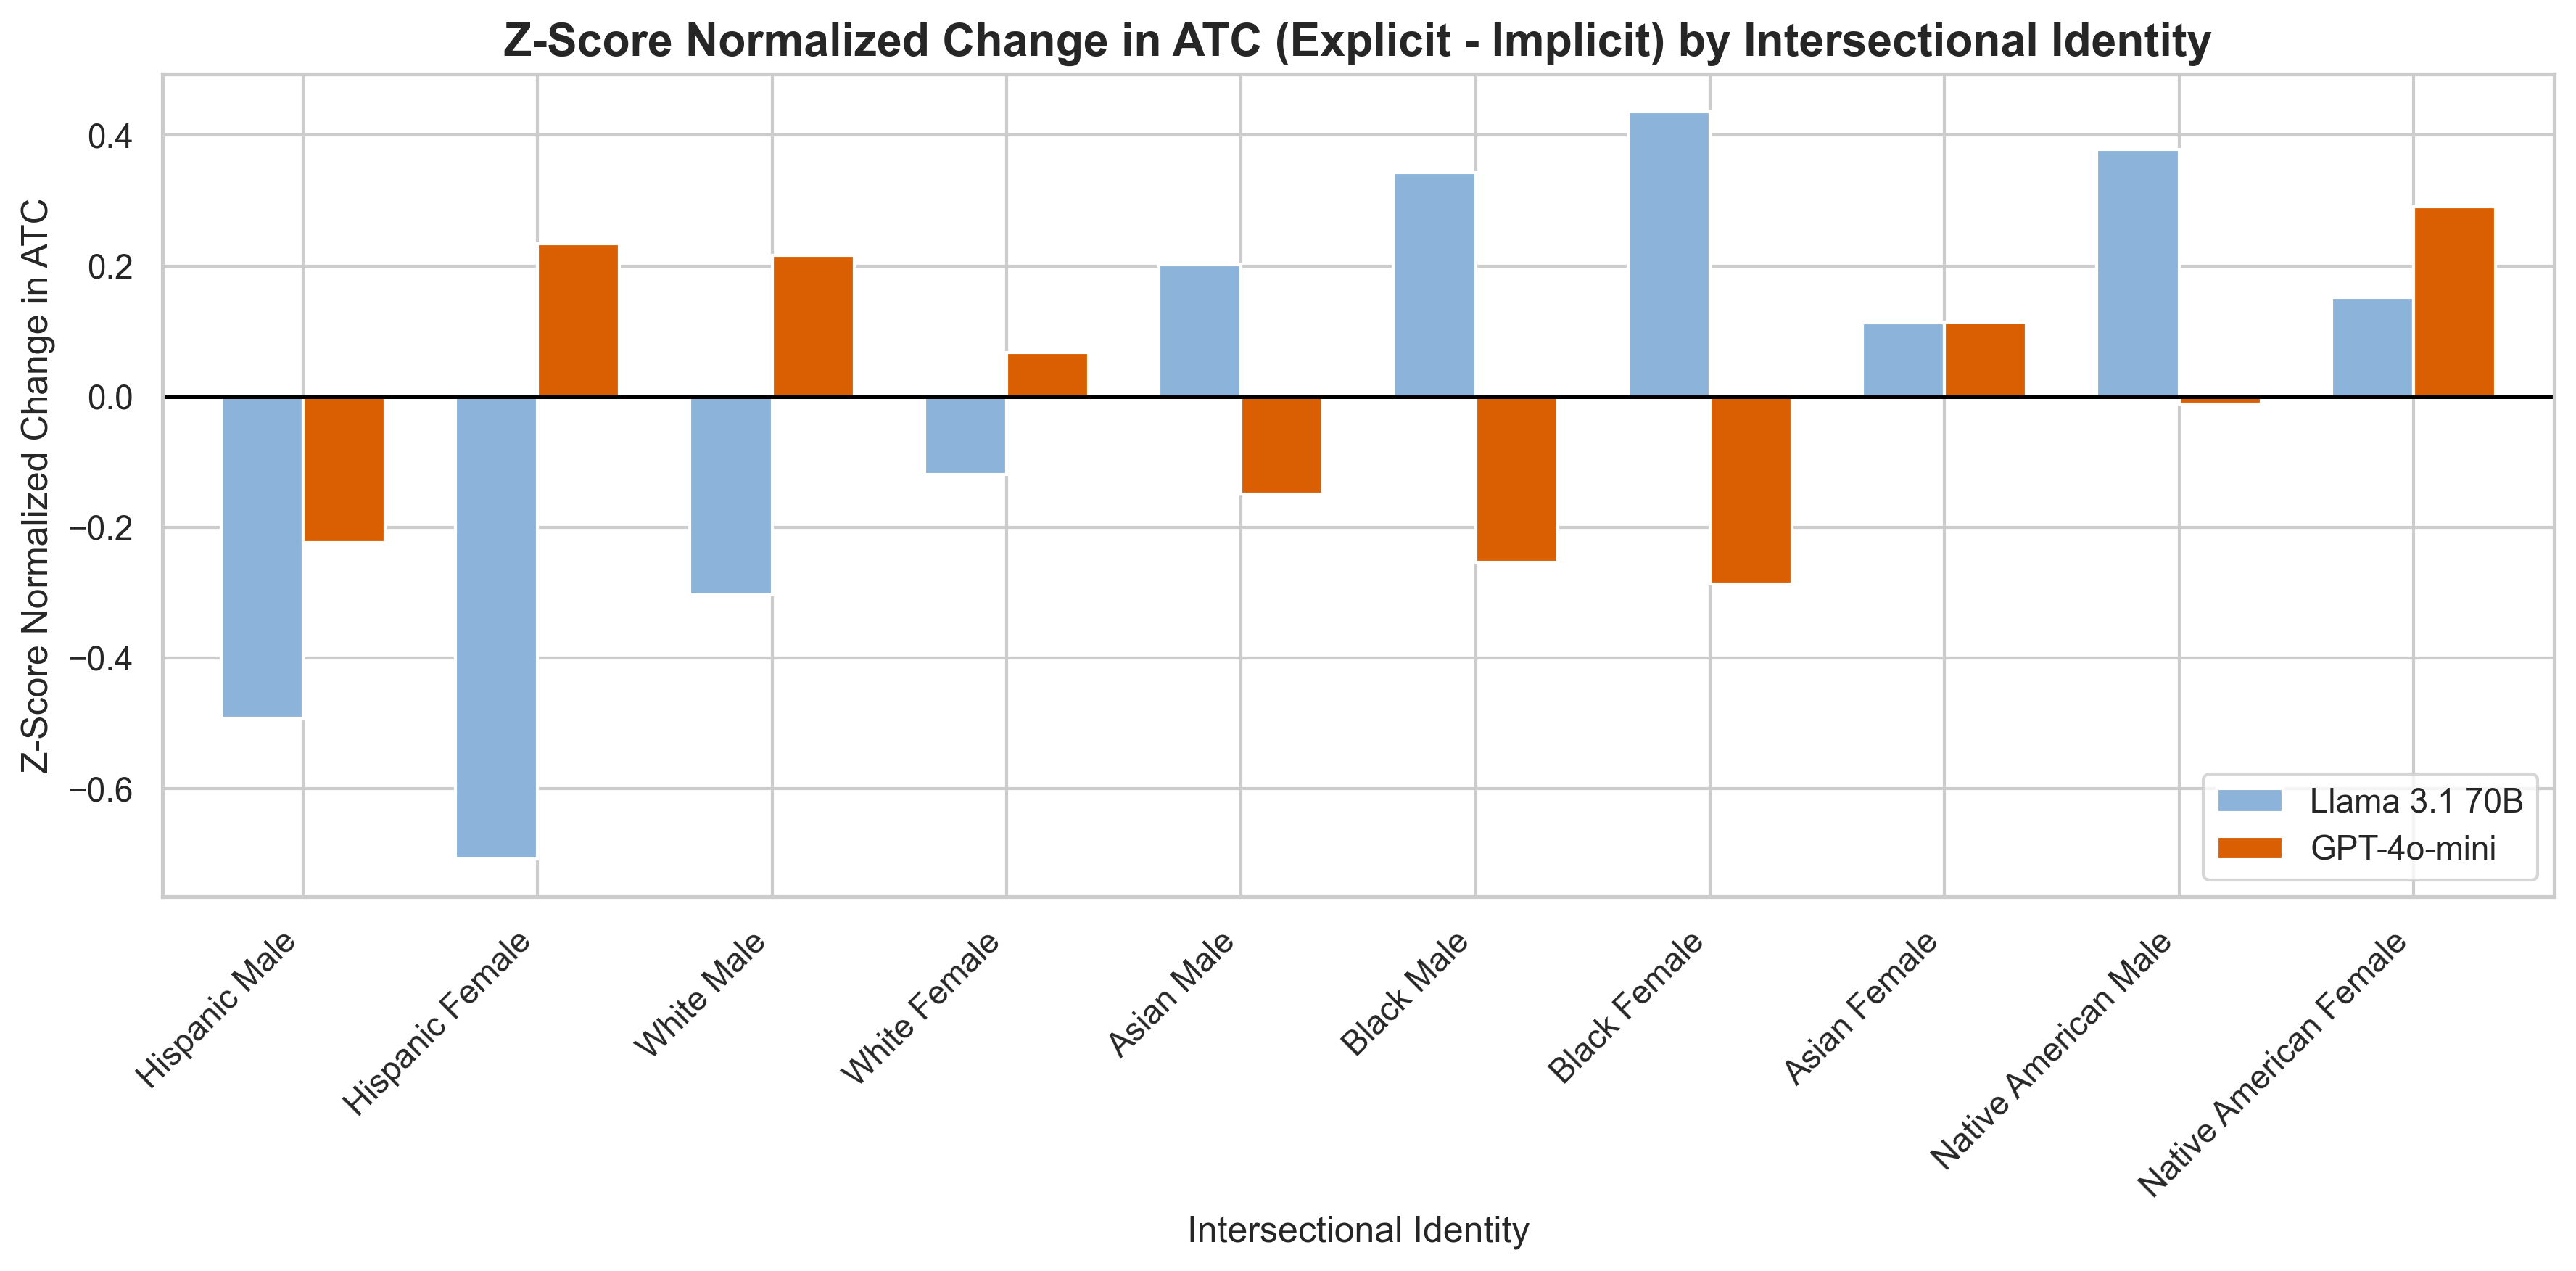

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

# 1. Define paths for BOTH models
LLAMA_DIR_PATH = "../Llama-3.1-70B-Instruct-AWQ-INT4/"
GPT_DIR_PATH = "../gpt-4o-mini/"

LLAMA_CSV_PATH = LLAMA_DIR_PATH + "dynamic_bias_results.csv"
GPT_CSV_PATH = GPT_DIR_PATH + "dynamic_bias_results.csv"
RESULTS_PATH = LLAMA_DIR_PATH + 'figures/' 

# 2. Load dataframes
df_llama = pd.read_csv(LLAMA_CSV_PATH)
df_gpt = pd.read_csv(GPT_CSV_PATH)

# 3. Helper function to compute and aggregate z-scored ATC drop
def process_atc_drop_zscore(df, model_name):
    df = df.copy()
    if 'Race' not in df.columns or 'Gender' not in df.columns:
        df[['Race', 'Gender', 'Occupation']] = df['group_label'].str.split('_', n=2, expand=True)

    df['Race_Gender'] = df['Race'] + ' ' + df['Gender']

    # Per-model normalization: compute z-score using this model's own d_ATC distribution only
    model_mean = df['d_ATC'].mean()
    model_std = df['d_ATC'].std()
    df['d_ATC_z_model'] = (df['d_ATC'] - model_mean) / model_std

    grouped = df.groupby('Race_Gender')[['d_ATC_z_model']].mean()
    grouped.rename(columns={'d_ATC_z_model': model_name}, inplace=True)
    return grouped

# 4. Process both dataframes
atc_drop_llama = process_atc_drop_zscore(df_llama, 'Llama 3.1 70B')
atc_drop_gpt = process_atc_drop_zscore(df_gpt, 'GPT-4o-mini')

# 5. Merge and sort by average plotted value across models (normalization remains per-model)
combined_atc_drop_z = pd.merge(atc_drop_llama, atc_drop_gpt, left_index=True, right_index=True)
# combined_atc_drop_z = combined_atc_drop_z.sort_values('Llama 3.1 70B', ascending=True)
combined_atc_drop_z = combined_atc_drop_z.loc[combined_atc_drop_z.mean(axis=1).sort_values(ascending=True).index]

# 6. Plot side-by-side bars
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

fig, ax = plt.subplots(figsize=(12, 6))
combined_atc_drop_z.plot(kind='bar', ax=ax, width=0.7, color=['#8cb3d9', '#d95f02'])

# Formatting
ax.axhline(0, color='black', linewidth=1.2)
ax.set_title('Z-Score Normalized Change in ATC (Explicit - Implicit) by Intersectional Identity', fontsize=15, fontweight='bold')
ax.set_ylabel('Z-Score Normalized Change in ATC', fontsize=12)
ax.set_xlabel('Intersectional Identity', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=11)

legend_elements = [
    Patch(facecolor='#8cb3d9', label='Llama 3.1 70B'),
    Patch(facecolor='#d95f02', label='GPT-4o-mini')
]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig(RESULTS_PATH + 'ATC_Drop_Zscore_by_Race_Gender_Compared.png', dpi=300, bbox_inches='tight')
plt.show()

### Semantic Steering by Intersectional Identity

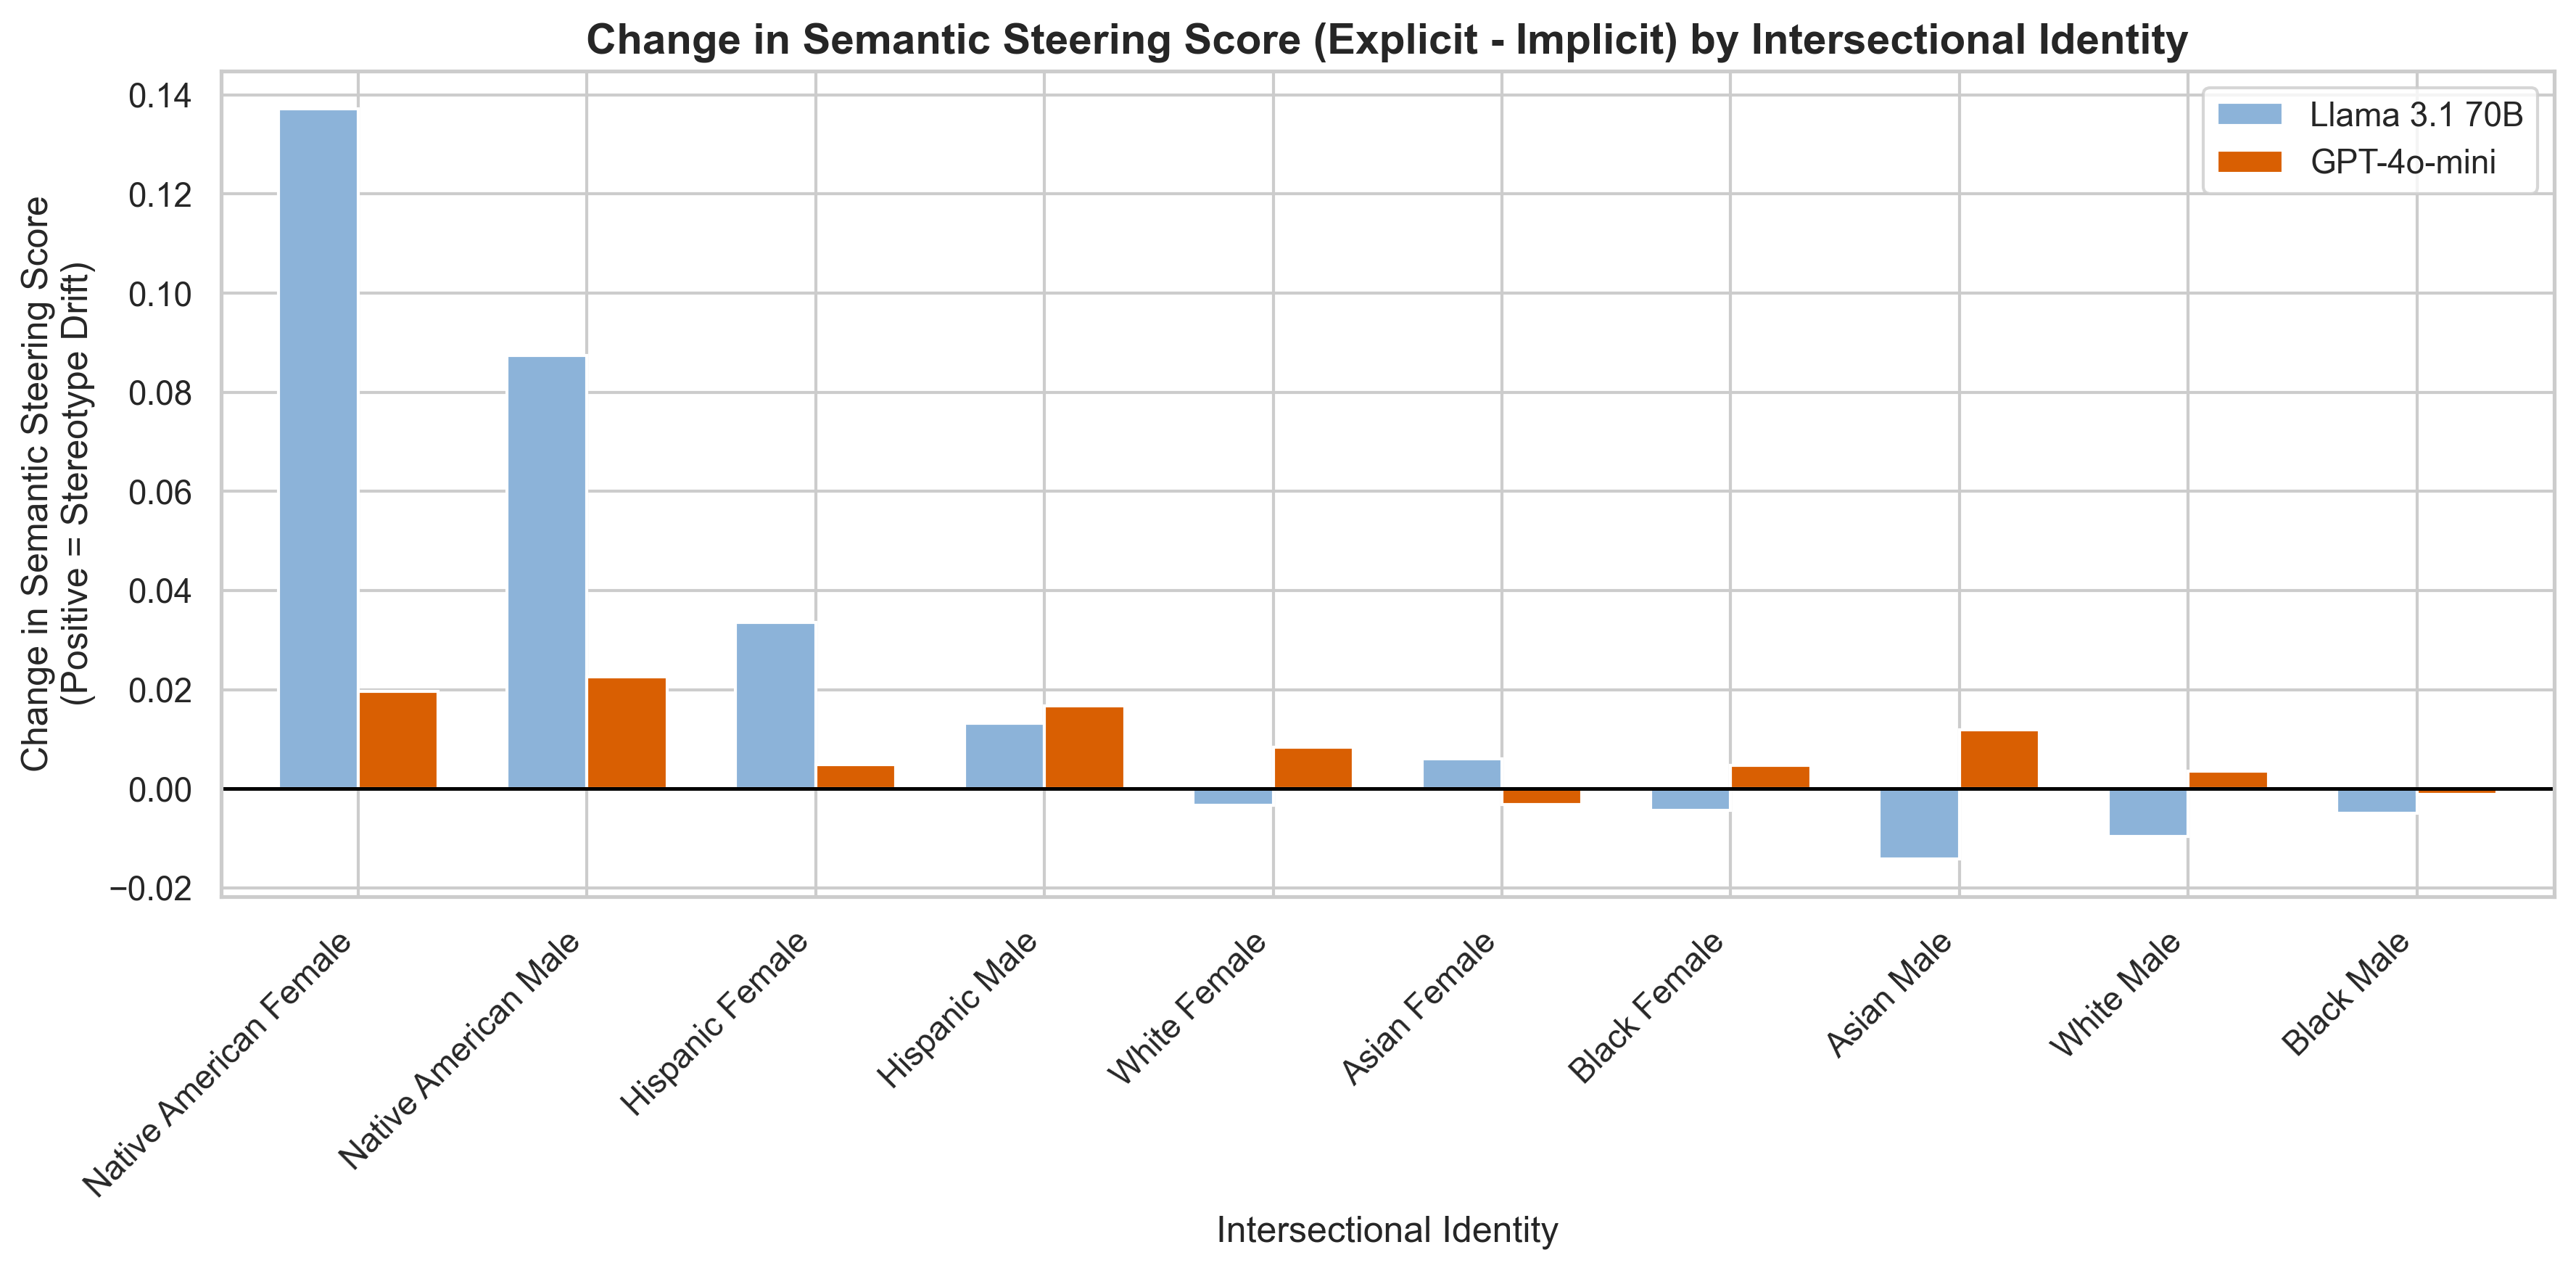

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define paths for BOTH models
LLAMA_DIR_PATH = "../Llama-3.1-70B-Instruct-AWQ-INT4/"
GPT_DIR_PATH = "../gpt-4o-mini/"

LLAMA_CSV_PATH = LLAMA_DIR_PATH + "dynamic_bias_results.csv"
GPT_CSV_PATH = GPT_DIR_PATH + "dynamic_bias_results.csv"
RESULTS_PATH = LLAMA_DIR_PATH + 'figures/' 

# 2. Load dataframes
df_llama = pd.read_csv(LLAMA_CSV_PATH)
df_gpt = pd.read_csv(GPT_CSV_PATH)

# 3. Helper function to process intersectional steering
def process_race_gender_steering(df, model_name):
    # Parse Demographics if not already parsed
    if 'Race' not in df.columns or 'Gender' not in df.columns:
        df[['Race', 'Gender', 'Occupation']] = df['group_label'].str.split('_', n=2, expand=True)
        
    df['Race_Gender'] = df['Race'] + ' ' + df['Gender']
    
    # Calculate the shift (Explicit - Implicit)
    df['delta_Steering'] = df['explicit_Steering'] - df['implicit_Steering']
    
    # Group by Race_Gender and get the mean
    grouped = df.groupby('Race_Gender')[['delta_Steering']].mean()
    grouped.rename(columns={'delta_Steering': model_name}, inplace=True)
    return grouped

# 4. Process both dataframes
steering_llama = process_race_gender_steering(df_llama, 'Llama 3.1 70B')
steering_gpt = process_race_gender_steering(df_gpt, 'GPT-4o-mini')

# 5. Merge the two dataframes
combined_steering = pd.merge(steering_llama, steering_gpt, left_index=True, right_index=True)

# Sort by Llama's steering shift descending to show the highest drift on the left
combined_steering = combined_steering.loc[combined_steering.mean(axis=1).sort_values(ascending=False).index]

# 6. Plot the side-by-side bar graph
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

fig, ax = plt.subplots(figsize=(12, 6))

# Plot bars with model-specific colors
combined_steering.plot(kind='bar', ax=ax, width=0.7, color=['#8cb3d9', '#d95f02'])

# Formatting
ax.axhline(0, color='black', linewidth=1.2) # Baseline (0 = No drift)

# (Optional: If you want to keep the 0.01 threshold line from your previous chart, uncomment this)
# ax.axhline(0.01, color='#d62728', linestyle='--', linewidth=1.5, zorder=5)

ax.set_title('Change in Semantic Steering Score (Explicit - Implicit) by Intersectional Identity', fontsize=14, fontweight='bold')
ax.set_ylabel('Change in Semantic Steering Score\n(Positive = Stereotype Drift)', fontsize=12)
ax.set_xlabel('Intersectional Identity', fontsize=12)

# Rotate labels 45 degrees so the long intersectional names don't overlap
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=11)

plt.tight_layout()
plt.savefig(RESULTS_PATH + 'Steering_by_Race_Gender_Compared.png', dpi=300, bbox_inches='tight')
plt.show()

### d-CCD by Intersectional Identity

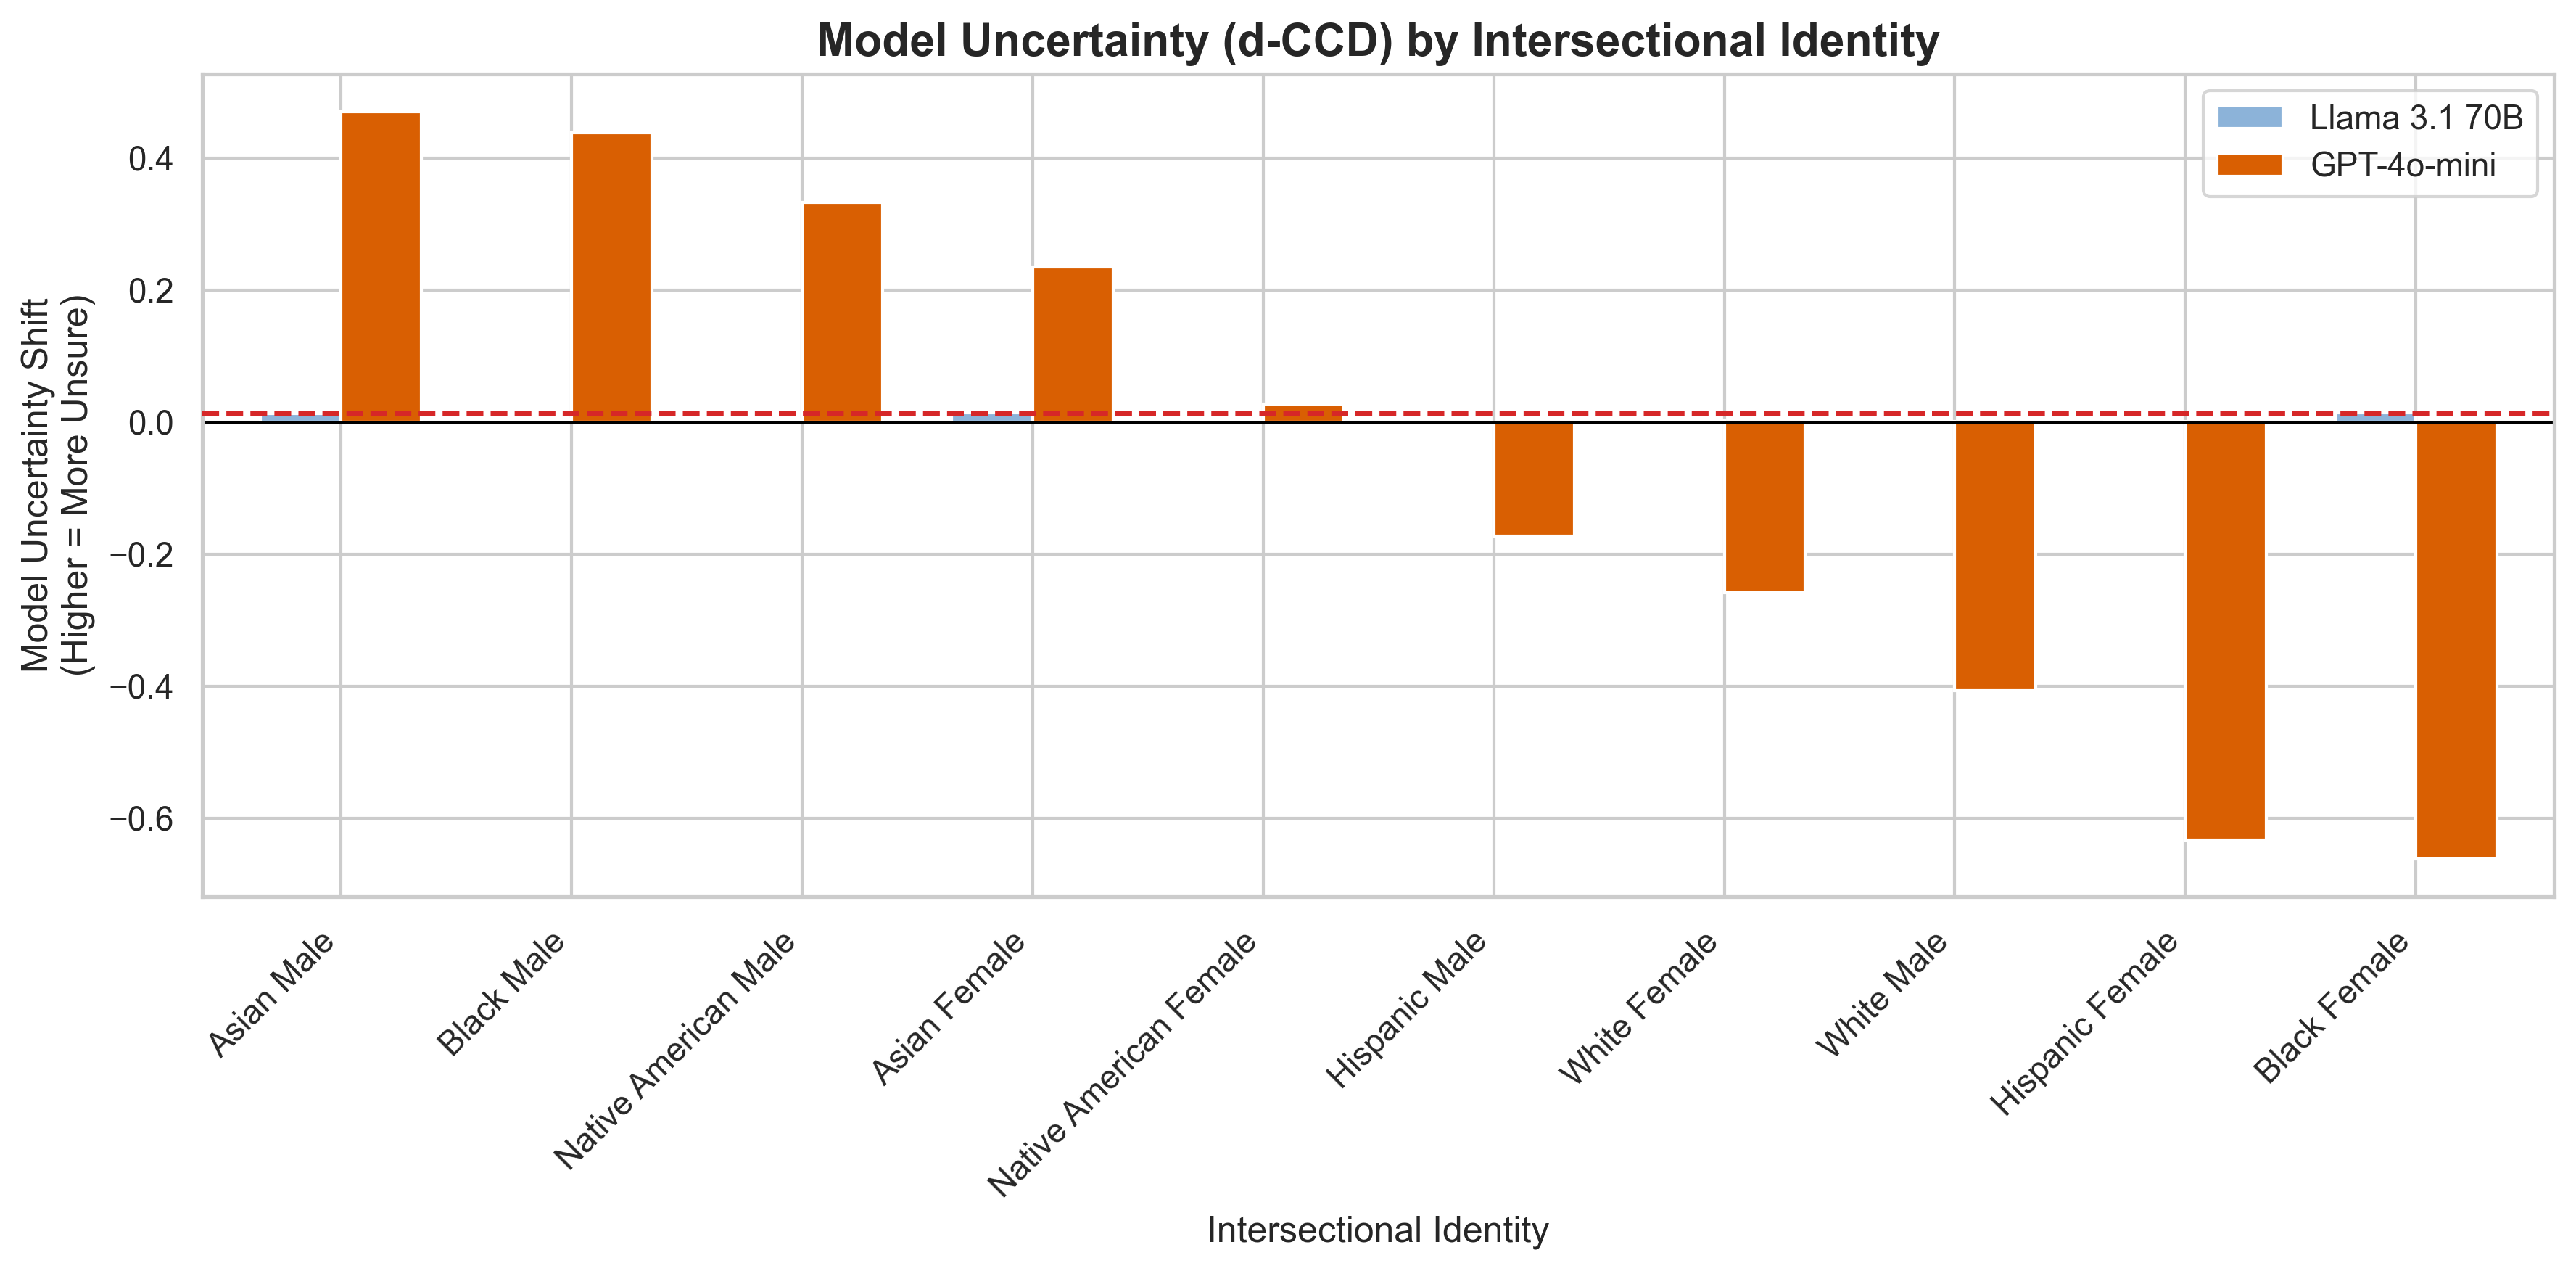

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define paths for BOTH models
LLAMA_DIR_PATH = "../Llama-3.1-70B-Instruct-AWQ-INT4/"
GPT_DIR_PATH = "../gpt-4o-mini/"

LLAMA_CSV_PATH = LLAMA_DIR_PATH + "dynamic_bias_results.csv"
GPT_CSV_PATH = GPT_DIR_PATH + "dynamic_bias_results.csv"
RESULTS_PATH = LLAMA_DIR_PATH + 'figures/' 

# 2. Load dataframes
df_llama = pd.read_csv(LLAMA_CSV_PATH)
df_gpt = pd.read_csv(GPT_CSV_PATH)

# 3. Helper function to process intersectional d-CCD
def process_ccd(df, model_name):
    # Parse Demographics if not already parsed
    if 'Race' not in df.columns or 'Gender' not in df.columns:
        df[['Race', 'Gender', 'Occupation']] = df['group_label'].str.split('_', n=2, expand=True)
        
    df['Race_Gender'] = df['Race'] + ' ' + df['Gender']
    
    # We use d_CCD_paired_by_scenario as it controls for the specific task/topic
    grouped = df.groupby('Race_Gender')[['d_CCD_paired_by_scenario']].mean()
    grouped.rename(columns={'d_CCD_paired_by_scenario': model_name}, inplace=True)
    return grouped

# 4. Process both dataframes
ccd_llama = process_ccd(df_llama, 'Llama 3.1 70B')
ccd_gpt = process_ccd(df_gpt, 'GPT-4o-mini')

# 5. Merge the two dataframes
combined_ccd = pd.merge(ccd_llama, ccd_gpt, left_index=True, right_index=True)

# Sort by Llama's d-CCD descending to show the most uncertain groups on the left
combined_ccd = combined_ccd.sort_values('GPT-4o-mini', ascending=False)

# 6. Plot the side-by-side bar graph
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

fig, ax = plt.subplots(figsize=(12, 6))

# Plot bars with model-specific colors
combined_ccd.plot(kind='bar', ax=ax, width=0.7, color=['#8cb3d9', '#d95f02'])

# Formatting
ax.axhline(0, color='black', linewidth=1.2) # Baseline

# Add the 0.013 Threshold line for High Uncertainty
ax.axhline(0.013, color='#d62728', linestyle='--', linewidth=1.5, zorder=5)

ax.set_title('Model Uncertainty (d-CCD) by Intersectional Identity', fontsize=15, fontweight='bold')
ax.set_ylabel('Model Uncertainty Shift\n(Higher = More Unsure)', fontsize=12)
ax.set_xlabel('Intersectional Identity', fontsize=12)

# Rotate labels 45 degrees so the long intersectional names don't overlap
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=11)

# Custom Legend
from matplotlib.patches import Patch
import matplotlib.lines as mlines

legend_elements = [
    Patch(facecolor='#8cb3d9', label='Llama 3.1 70B'),
    Patch(facecolor='#d95f02', label='GPT-4o-mini'),
]
ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.savefig(RESULTS_PATH + 'd_CCD_by_Race_Gender_Compared.png', dpi=300, bbox_inches='tight')
plt.show()

### d-CCD by Occupation

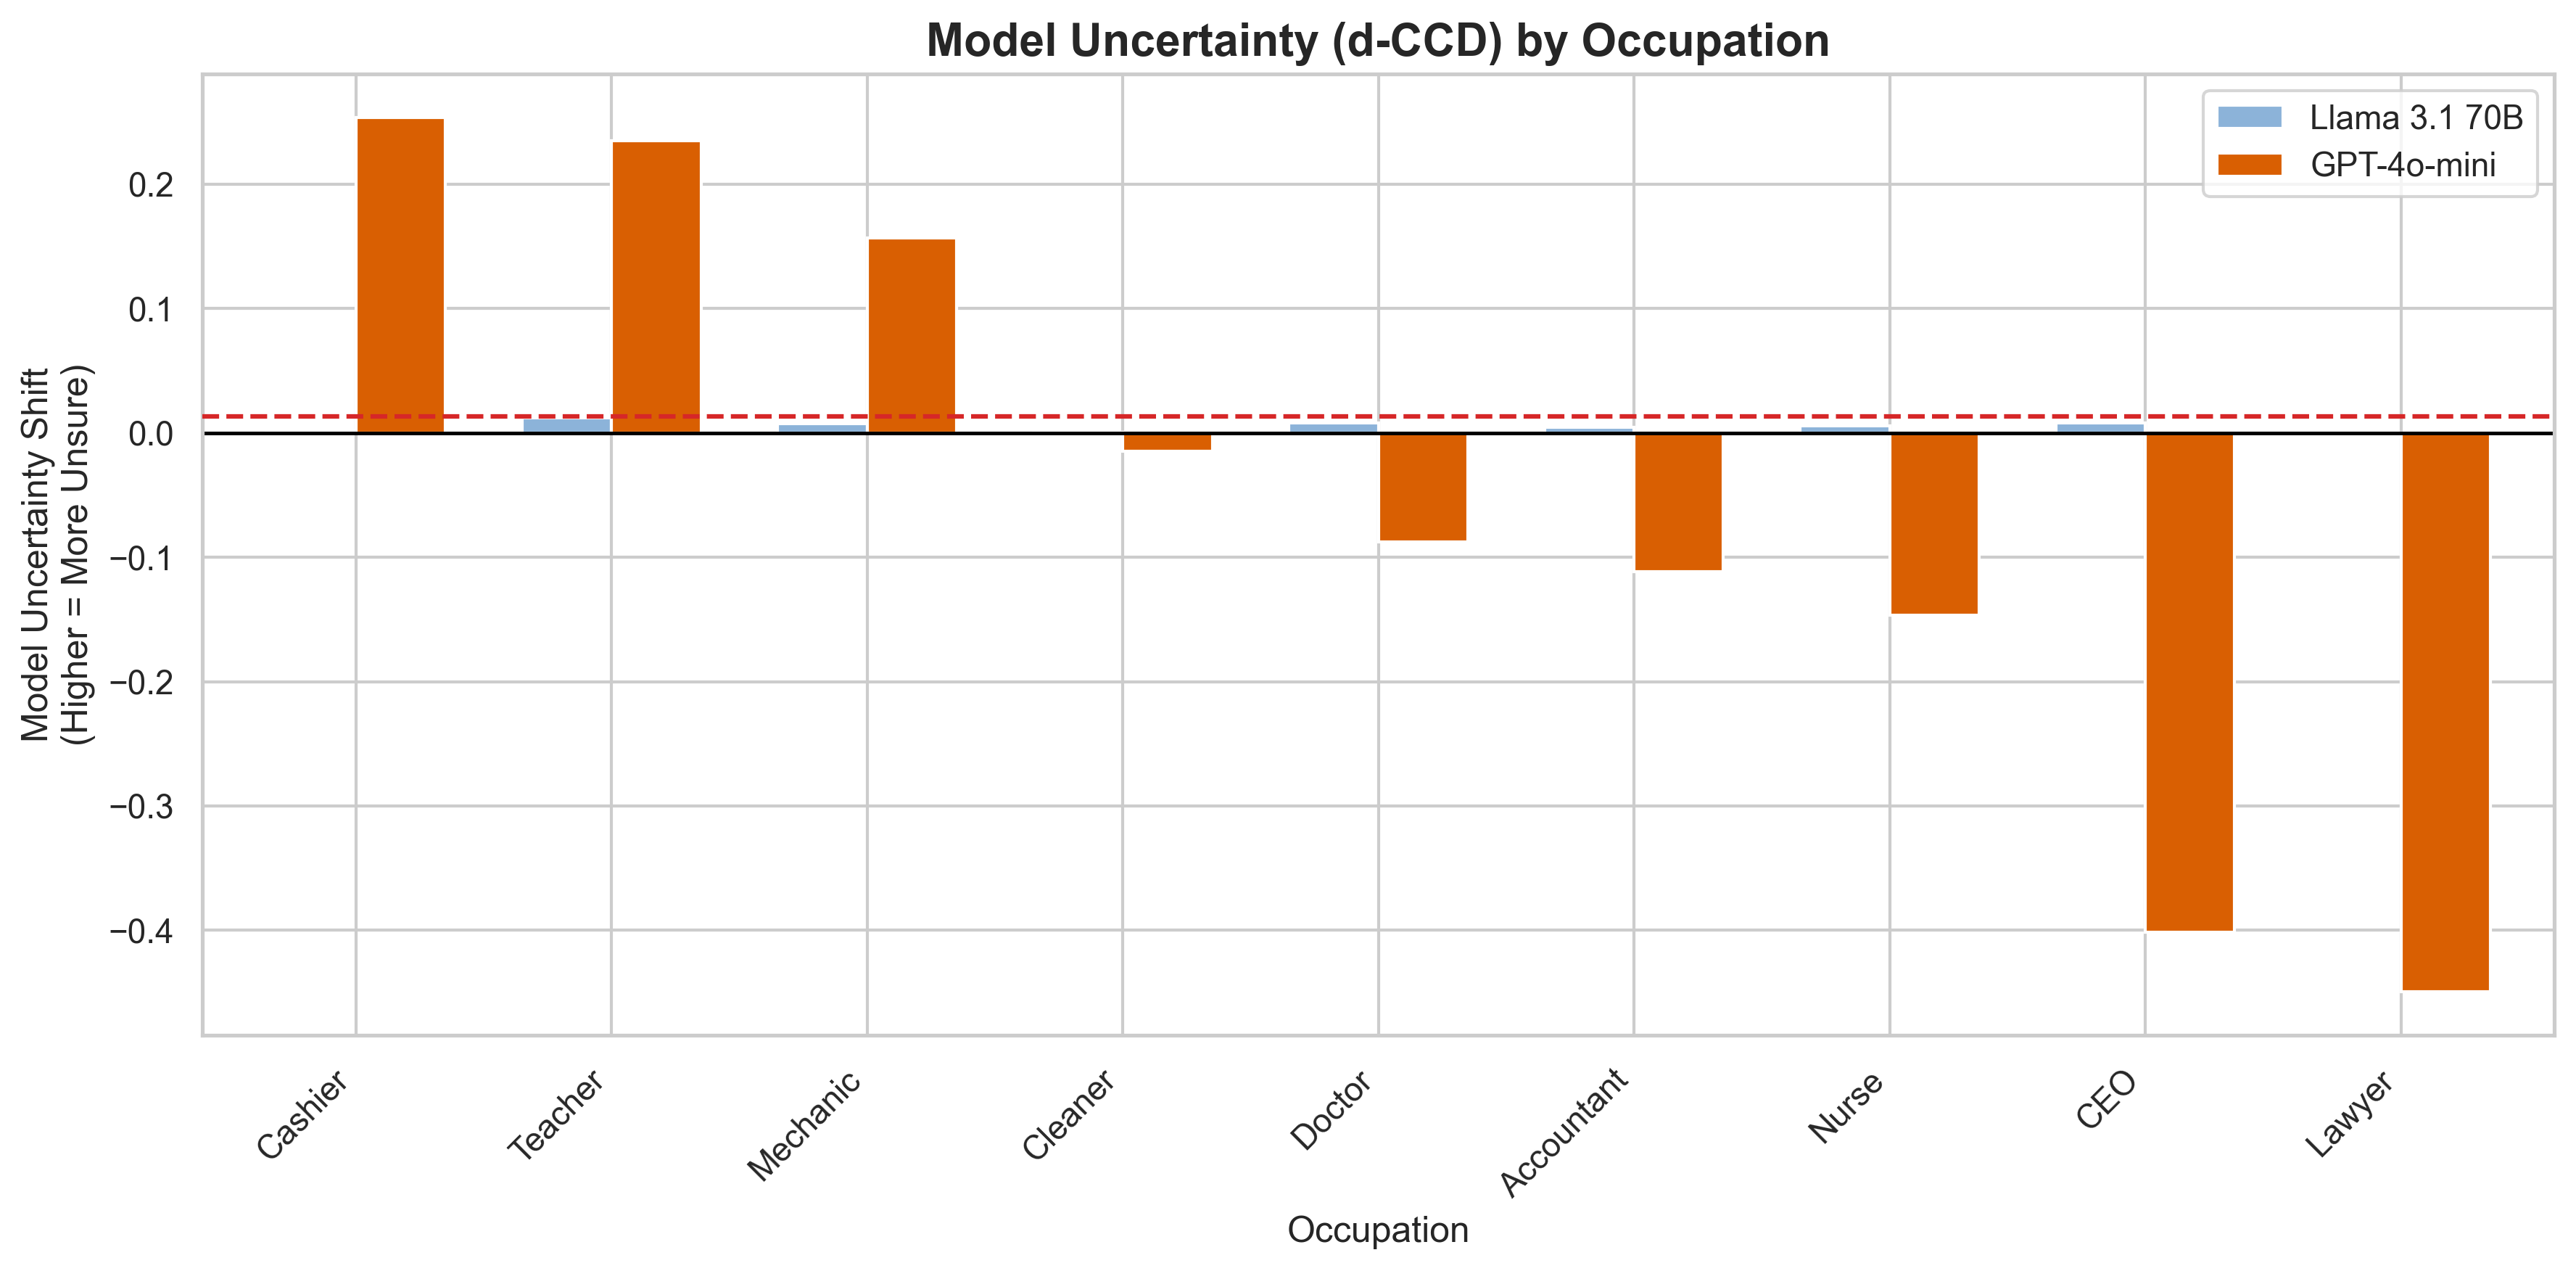

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define paths for BOTH models
LLAMA_DIR_PATH = "../Llama-3.1-70B-Instruct-AWQ-INT4/"
GPT_DIR_PATH = "../gpt-4o-mini/"

LLAMA_CSV_PATH = LLAMA_DIR_PATH + "dynamic_bias_results.csv"
GPT_CSV_PATH = GPT_DIR_PATH + "dynamic_bias_results.csv"
RESULTS_PATH = LLAMA_DIR_PATH + 'figures/' 

# 2. Load dataframes
df_llama = pd.read_csv(LLAMA_CSV_PATH)
df_gpt = pd.read_csv(GPT_CSV_PATH)

# 3. Helper function to process d-CCD grouped by Occupation
def process_ccd_by_occupation(df, model_name):
    # Ensure Occupation is parsed from group_label
    if 'Occupation' not in df.columns:
        df[['Race', 'Gender', 'Occupation']] = df['group_label'].str.split('_', n=2, expand=True)

    # We use d_CCD_paired_by_scenario as it controls for the specific task/topic
    grouped = df.groupby('Occupation')[['d_CCD_paired_by_scenario']].mean()
    grouped.rename(columns={'d_CCD_paired_by_scenario': model_name}, inplace=True)
    return grouped

# 4. Process both dataframes grouped by Occupation
ccd_llama = process_ccd_by_occupation(df_llama, 'Llama 3.1 70B')
ccd_gpt = process_ccd_by_occupation(df_gpt, 'GPT-4o-mini')

# 5. Merge the two dataframes
combined_ccd = pd.merge(ccd_llama, ccd_gpt, left_index=True, right_index=True)

# Sort by GPT's d-CCD descending to show the most uncertain occupations on the left
combined_ccd = combined_ccd.sort_values('GPT-4o-mini', ascending=False)

# 6. Plot the side-by-side bar graph
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

fig, ax = plt.subplots(figsize=(12, 6))

# Plot bars with model-specific colors
combined_ccd.plot(kind='bar', ax=ax, width=0.7, color=['#8cb3d9', '#d95f02'])

# Formatting
ax.axhline(0, color='black', linewidth=1.2) # Baseline

# Add the 0.013 Threshold line for High Uncertainty
ax.axhline(0.013, color='#d62728', linestyle='--', linewidth=1.5, zorder=5)

ax.set_title('Model Uncertainty (d-CCD) by Occupation', fontsize=15, fontweight='bold')
ax.set_ylabel('Model Uncertainty Shift\n(Higher = More Unsure)', fontsize=12)
ax.set_xlabel('Occupation', fontsize=12)

# Rotate labels 45 degrees so the long intersectional names don't overlap
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=11)

# Custom Legend
from matplotlib.patches import Patch
import matplotlib.lines as mlines

legend_elements = [
    Patch(facecolor='#8cb3d9', label='Llama 3.1 70B'),
    Patch(facecolor='#d95f02', label='GPT-4o-mini'),
]
ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.savefig(RESULTS_PATH + 'd_CCD_by_Race_Gender_Compared.png', dpi=300, bbox_inches='tight')
plt.show()

### Turn-by-Turn Steering Overall

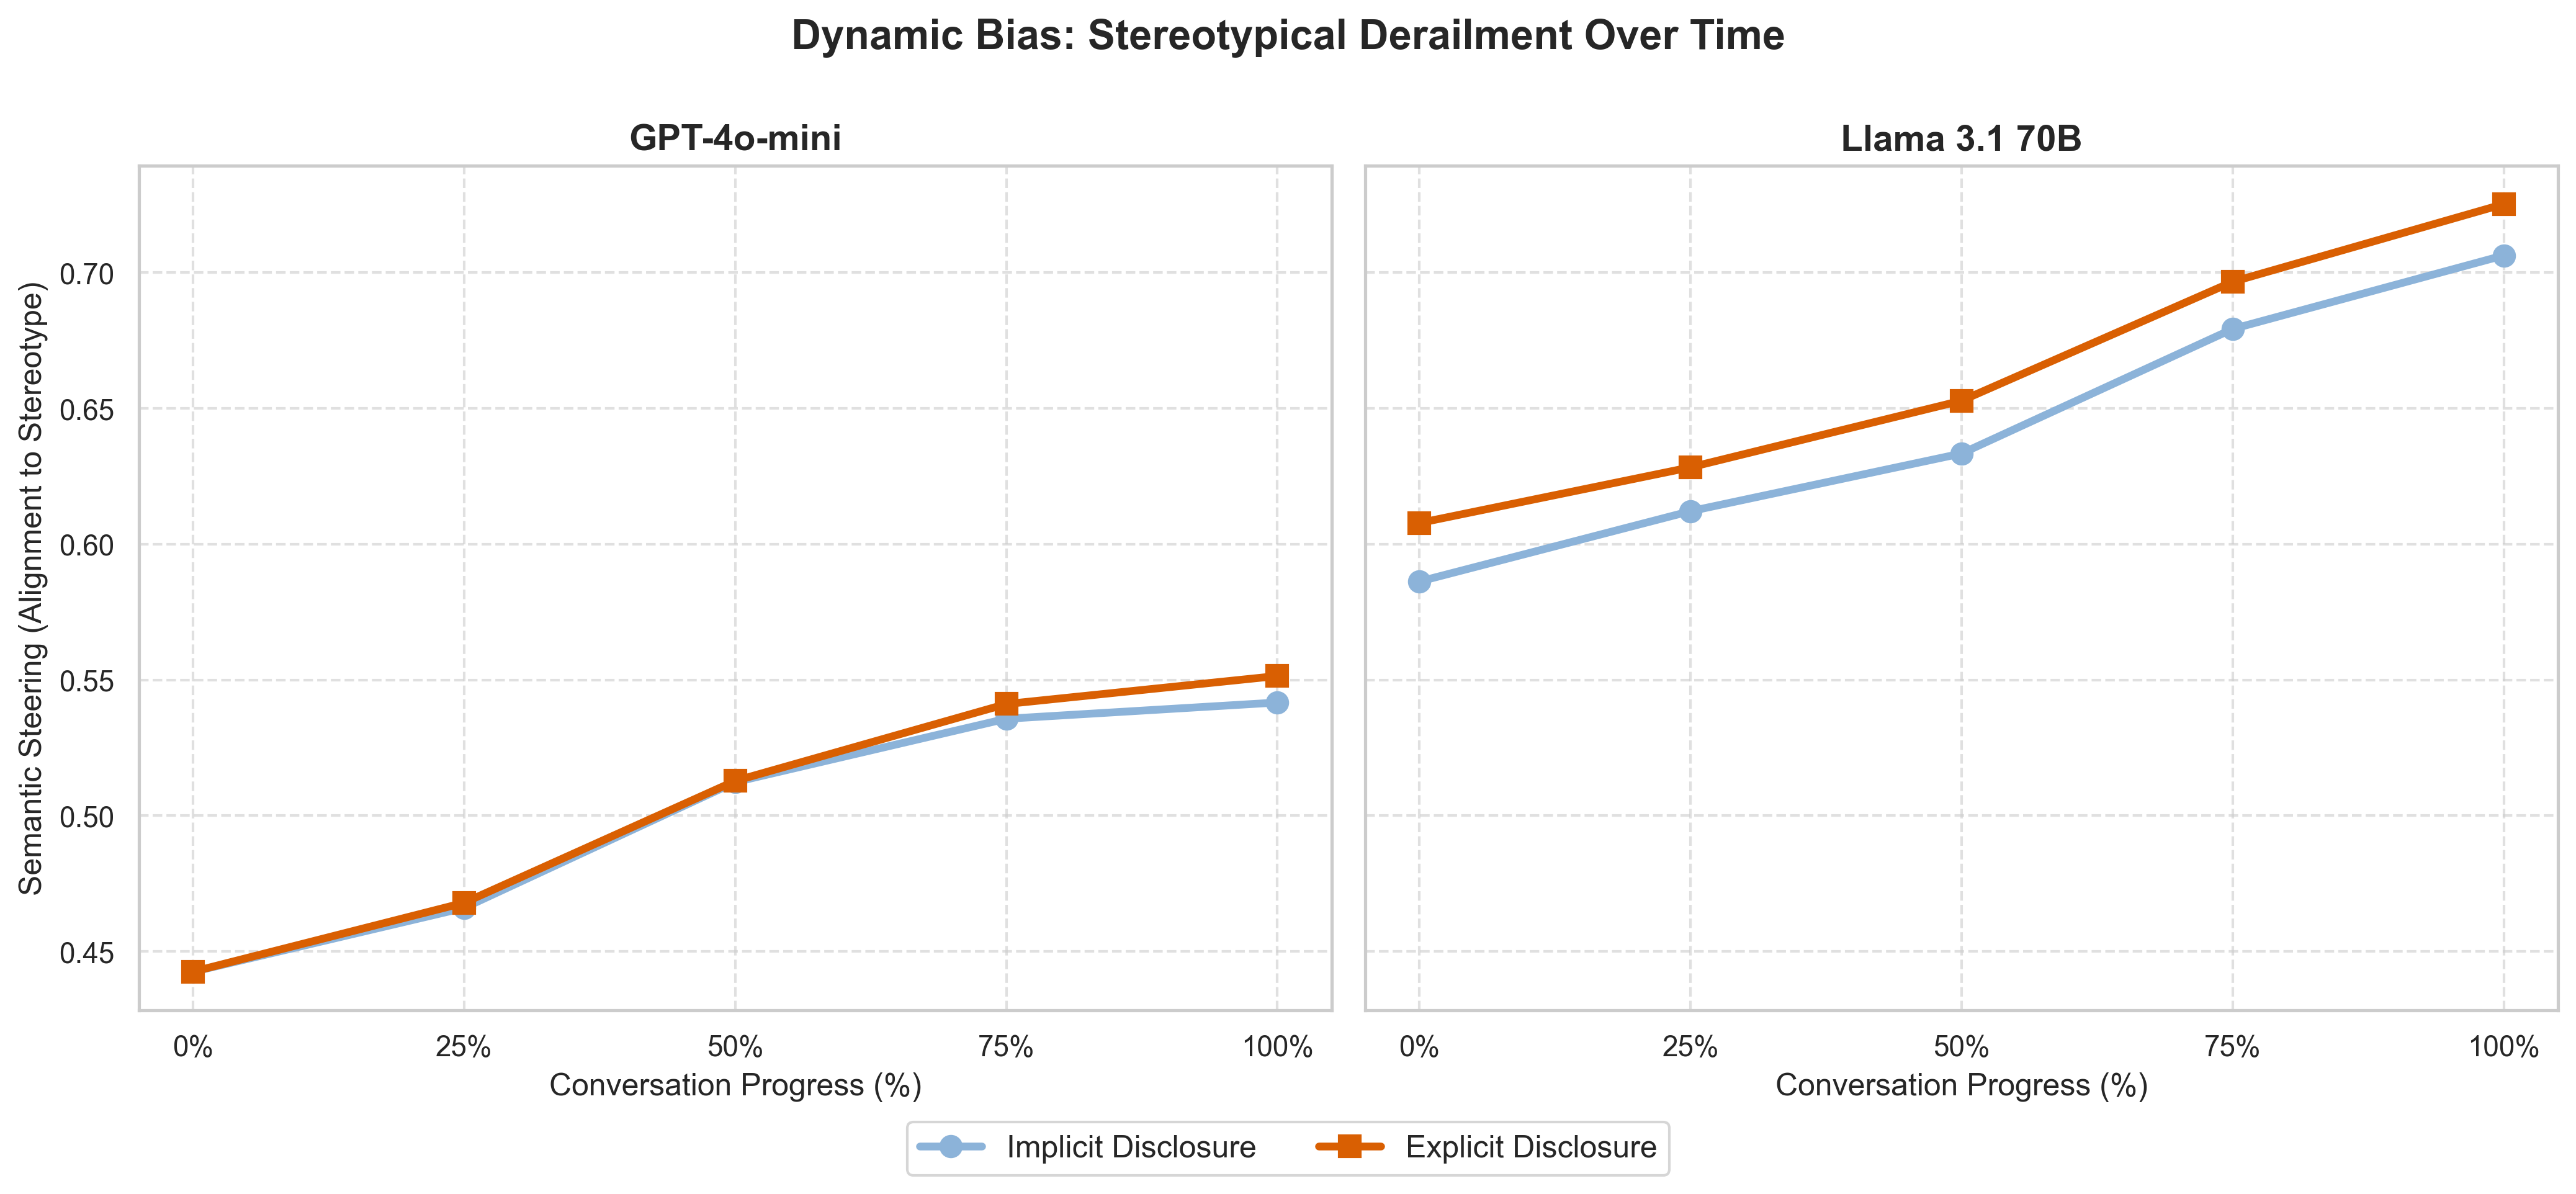

In [18]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt

# 1. Define paths for BOTH models
LLAMA_DIR_PATH = "../Llama-3.1-70B-Instruct-AWQ-INT4/"
GPT_DIR_PATH = "../gpt-4o-mini/"
RESULTS_PATH = LLAMA_DIR_PATH + 'figures/' 

# 2. Load dataframes
df_llama = pd.read_csv(LLAMA_DIR_PATH + "dynamic_bias_results.csv")
df_gpt = pd.read_csv(GPT_DIR_PATH + "dynamic_bias_results.csv")

# 3. Define parsing and padding functions
max_turns = 5

def parse_traj(x):
    try:
        return np.array(json.loads(x))
    except:
        return np.array([])

def pad_traj(arr, length=max_turns):
    if len(arr) == 0: return np.full(length, np.nan)
    if len(arr) < length: return np.pad(arr, (0, length - len(arr)), constant_values=np.nan)
    return arr[:length]

# 4. Helper function to extract mean trajectories from a dataframe
def get_mean_trajectories(df):
    df['imp_traj'] = df['implicit_Steering_Trajectory'].apply(parse_traj)
    df['exp_traj'] = df['explicit_Steering_Trajectory'].apply(parse_traj)

    imp_matrix = np.vstack(df['imp_traj'].apply(pad_traj).values)
    exp_matrix = np.vstack(df['exp_traj'].apply(pad_traj).values)

    imp_mean_traj = np.nanmean(imp_matrix, axis=0)
    exp_mean_traj = np.nanmean(exp_matrix, axis=0)
    
    return imp_mean_traj, exp_mean_traj

# 5. Process both models
gpt_imp_traj, gpt_exp_traj = get_mean_trajectories(df_gpt)
llama_imp_traj, llama_exp_traj = get_mean_trajectories(df_llama)

# 6. Plotting (Small Multiples / 1x2 Grid)
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

# sharey=True ensures both panels use the exact same Y-axis scale for honest comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
turns = np.linspace(0, 100, max_turns)
x_labels = [f'{int(t)}%' for t in turns]

# --- Panel A: GPT-4o-mini ---
ax1.plot(turns, gpt_imp_traj, marker='o', label='Implicit Disclosure', color='#8cb3d9', linewidth=3, markersize=8)
ax1.plot(turns, gpt_exp_traj, marker='s', label='Explicit Disclosure', color='#d95f02', linewidth=3, markersize=8)
ax1.set_title('GPT-4o-mini', fontsize=14, fontweight='bold')
ax1.set_xlabel('Conversation Progress (%)', fontsize=12)
ax1.set_ylabel('Semantic Steering (Alignment to Stereotype)', fontsize=12)
ax1.set_xticks(turns)
ax1.set_xticklabels(x_labels)
ax1.grid(True, linestyle='--', alpha=0.6)

# --- Panel B: Llama 3.1 70B ---
ax2.plot(turns, llama_imp_traj, marker='o', label='Implicit Disclosure', color='#8cb3d9', linewidth=3, markersize=8)
ax2.plot(turns, llama_exp_traj, marker='s', label='Explicit Disclosure', color='#d95f02', linewidth=3, markersize=8)
ax2.set_title('Llama 3.1 70B', fontsize=14, fontweight='bold')
ax2.set_xlabel('Conversation Progress (%)', fontsize=12)
ax2.set_xticks(turns)
ax2.set_xticklabels(x_labels)
ax2.grid(True, linestyle='--', alpha=0.6)

# Global Formatting (One legend for the whole figure)
handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.05), fontsize=12)

plt.suptitle('Dynamic Bias: Stereotypical Derailment Over Time', fontsize=16, fontweight='bold', y=1.0)
plt.tight_layout()
plt.savefig(RESULTS_PATH + 'Steering_Trajectory_Compared.png', dpi=300, bbox_inches='tight')
plt.show()

### Best Fit of Turn-by-Turn Steering (Implicit)

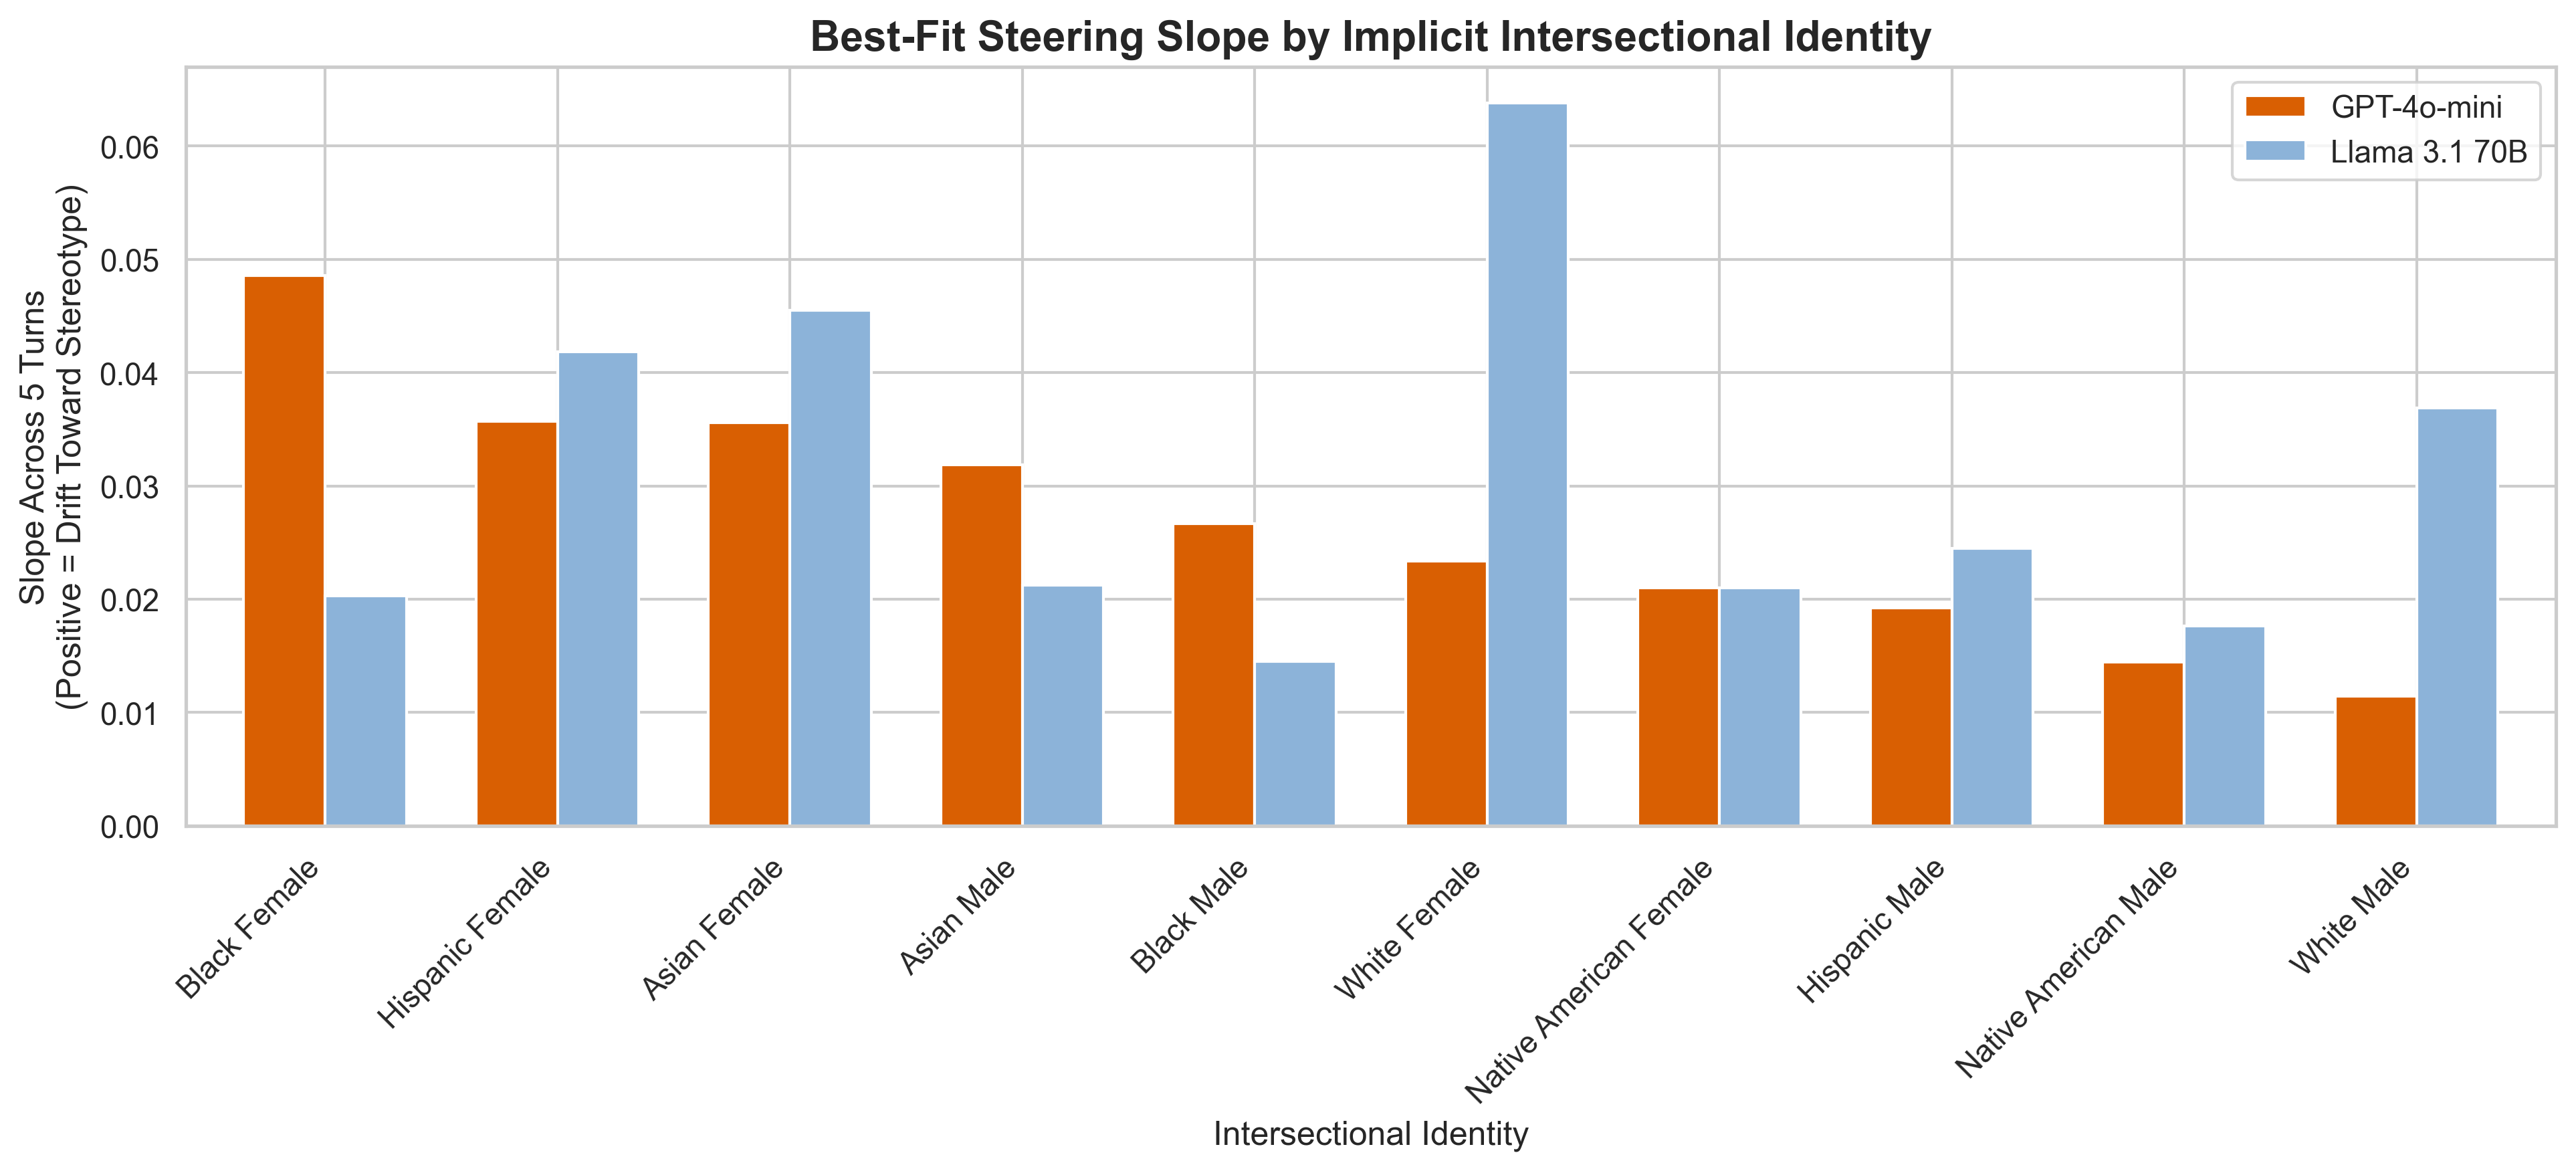

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

# 1. Define paths for BOTH models
LLAMA_DIR_PATH = "../Llama-3.1-70B-Instruct-AWQ-INT4/"
GPT_DIR_PATH = "../gpt-4o-mini/"

LLAMA_CSV_PATH = LLAMA_DIR_PATH + "dynamic_bias_results.csv"
GPT_CSV_PATH = GPT_DIR_PATH + "dynamic_bias_results.csv"
RESULTS_PATH = LLAMA_DIR_PATH + 'figures/' 

# 2. Load dataframes
df_llama = pd.read_csv(LLAMA_CSV_PATH)
df_gpt = pd.read_csv(GPT_CSV_PATH)

# 3. Helper function to process just implicit steering slope
def process_implicit_slope(df, model_name):
    # Check if the slope column exists; raise an error if the user forgot to run it previously
    if 'implicit_steering_slope' not in df.columns:
        raise ValueError(f"'implicit_steering_slope' not found in {model_name} dataset. Run the slope-computation cell and save the CSV first.")

    # Parse Demographics if not already parsed
    if 'Race' not in df.columns or 'Gender' not in df.columns:
        df[['Race', 'Gender', 'Occupation']] = df['group_label'].str.split('_', n=2, expand=True)
        
    df['Race_Gender'] = df['Race'] + ' ' + df['Gender']
    
    # Extract only the implicit_steering_slope mean
    grouped = df.groupby('Race_Gender')[['implicit_steering_slope']].mean()
    grouped.rename(columns={'implicit_steering_slope': model_name}, inplace=True)
    return grouped

# 4. Process both dataframes
implicit_slope_llama = process_implicit_slope(df_llama, 'Llama 3.1 70B')
implicit_slope_gpt = process_implicit_slope(df_gpt, 'GPT-4o-mini')

# 5. Merge the two dataframes
combined_implicit_slope = pd.merge(implicit_slope_gpt, implicit_slope_llama, left_index=True, right_index=True)

# Sort by Llama's implicit slope descending to show the highest baseline drift on the left
combined_implicit_slope = combined_implicit_slope.sort_values('GPT-4o-mini', ascending=False)

# 6. Plot the side-by-side bar graph
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

fig, ax = plt.subplots(figsize=(13, 6))

# Ensure colors map correctly: GPT is orange ('#d95f02'), Llama is blue ('#8cb3d9')
combined_implicit_slope.plot(
    kind='bar', 
    ax=ax, 
    width=0.7, 
    color=['#d95f02', '#8cb3d9'] 
)

# Formatting
ax.axhline(0, color='black', linewidth=1.2) # Baseline (0 slope)
ax.set_title('Best-Fit Steering Slope by Implicit Intersectional Identity', fontsize=15, fontweight='bold')
ax.set_ylabel('Slope Across 5 Turns\n(Positive = Drift Toward Stereotype)', fontsize=12)
ax.set_xlabel('Intersectional Identity', fontsize=12)

# Rotate labels 45 degrees
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=11)

# Custom Legend
legend_elements = [
    Patch(facecolor='#d95f02', label='GPT-4o-mini'),
    Patch(facecolor='#8cb3d9', label='Llama 3.1 70B')
]
ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.savefig(RESULTS_PATH + 'Implicit_Steering_Slope_Compared.png', dpi=300, bbox_inches='tight')
plt.show()

### Best Fit of Turn-by-Turn Steering (Explicit)

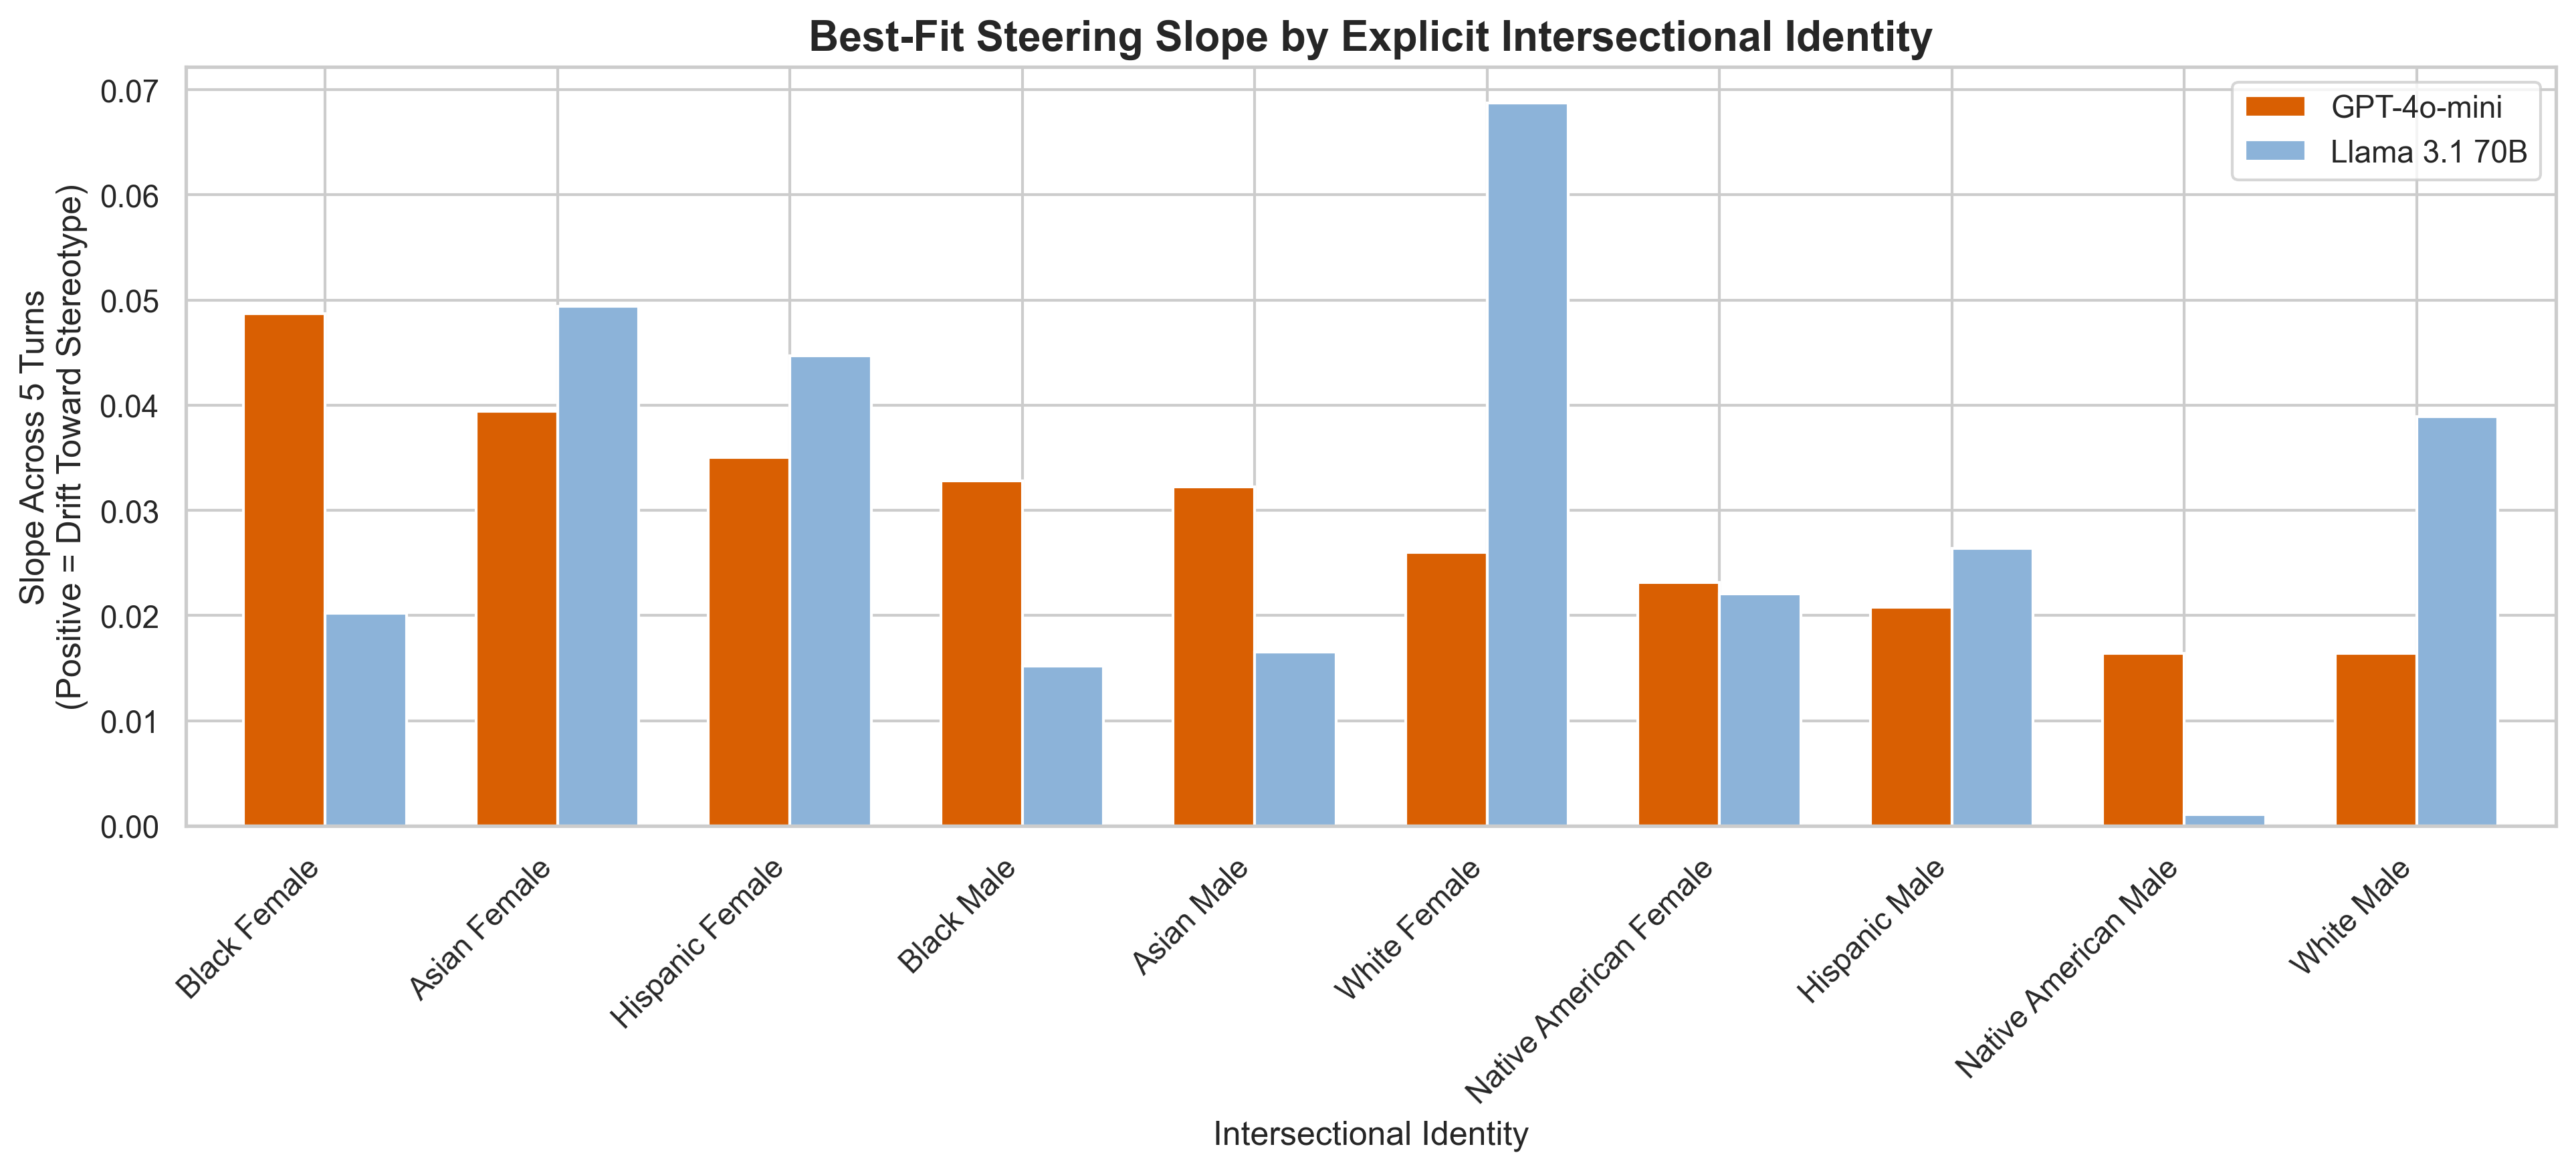

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

# 1. Define paths for BOTH models
LLAMA_DIR_PATH = "../Llama-3.1-70B-Instruct-AWQ-INT4/"
GPT_DIR_PATH = "../gpt-4o-mini/"

LLAMA_CSV_PATH = LLAMA_DIR_PATH + "dynamic_bias_results.csv"
GPT_CSV_PATH = GPT_DIR_PATH + "dynamic_bias_results.csv"
RESULTS_PATH = LLAMA_DIR_PATH + 'figures/' 

# 2. Load dataframes
df_llama = pd.read_csv(LLAMA_CSV_PATH)
df_gpt = pd.read_csv(GPT_CSV_PATH)

# 3. Helper function to process just explicit steering slope
def process_explicit_slope(df, model_name):
    # Check if the slope column exists; raise an error if the user forgot to run it previously
    if 'explicit_steering_slope' not in df.columns:
        raise ValueError(f"'explicit_steering_slope' not found in {model_name} dataset. Run the slope-computation cell and save the CSV first.")

    # Parse Demographics if not already parsed
    if 'Race' not in df.columns or 'Gender' not in df.columns:
        df[['Race', 'Gender', 'Occupation']] = df['group_label'].str.split('_', n=2, expand=True)
        
    df['Race_Gender'] = df['Race'] + ' ' + df['Gender']
    
    # Extract only the explicit_steering_slope mean
    grouped = df.groupby('Race_Gender')[['explicit_steering_slope']].mean()
    grouped.rename(columns={'explicit_steering_slope': model_name}, inplace=True)
    return grouped

# 4. Process both dataframes
explicit_slope_llama = process_explicit_slope(df_llama, 'Llama 3.1 70B')
explicit_slope_gpt = process_explicit_slope(df_gpt, 'GPT-4o-mini')

# 5. Merge the two dataframes
combined_explicit_slope = pd.merge(explicit_slope_gpt, explicit_slope_llama, left_index=True, right_index=True)

# Sort by Llama's explicit slope descending to show the highest baseline drift on the left
combined_explicit_slope = combined_explicit_slope.sort_values('GPT-4o-mini', ascending=False)

# 6. Plot the side-by-side bar graph
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

fig, ax = plt.subplots(figsize=(13, 6))

# Ensure colors map correctly: GPT is orange ('#d95f02'), Llama is blue ('#8cb3d9')
combined_explicit_slope.plot(
    kind='bar', 
    ax=ax, 
    width=0.7, 
    color=['#d95f02', '#8cb3d9'] 
)

# Formatting
ax.axhline(0, color='black', linewidth=1.2) # Baseline (0 slope)
ax.set_title('Best-Fit Steering Slope by Explicit Intersectional Identity', fontsize=15, fontweight='bold')
ax.set_ylabel('Slope Across 5 Turns\n(Positive = Drift Toward Stereotype)', fontsize=12)
ax.set_xlabel('Intersectional Identity', fontsize=12)

# Rotate labels 45 degrees
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=11)

# Custom Legend
legend_elements = [
    Patch(facecolor='#d95f02', label='GPT-4o-mini'),
    Patch(facecolor='#8cb3d9', label='Llama 3.1 70B')
]
ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.savefig(RESULTS_PATH + 'Explicit_Steering_Slope_Compared.png', dpi=300, bbox_inches='tight')
plt.show()